### Advanced Genomics project
#### A.Y. 2023-24
student : Simone Corbetta (13537A)

email : simone.corbetta1@studenti.unimi.it

In [ ]:
import  matplotlib
import numpy as np
from Bio import Phylo
import pandas as pd
import re
from Bio import Entrez
from Bio import SeqIO
import matplotlib.pyplot as plt
import csv
from scipy.cluster.hierarchy import linkage
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import fcluster
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
np.random.seed(42)
from Levenshtein import distance
import genieclust
from scipy.stats import mannwhitneyu
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer
from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.decomposition import TruncatedSVD

## Introduction

The 16S ribosomal RNA gene is the most widely used marker gene in microbial ecology. Counts of 16S sequence
variants are used to estimate proportions of bacterial and archaeal taxa in microbial
communities.

Because different organisms contain different 16S gene copy numbers (GCNs), sequence variant counts
are biased towards clades with greater GCNs.
Several tools have recently been developed for predicting GCNs using phylogenetic methods and based on sequenced genomes,
in order to correct for this bias.
16S GCNs could only be accurately predicted for a limited fraction of taxa, namely taxa with closely to moderately related
representatives (15% divergence in the 16S rRNA gene)

The idea is to implement a KNN algorithm for classification to predict the number of copies of 16S based on the similarity 
of 16S sequences of microorganisms with 16S sequences of microorganisms which have a known number of 16S copies.
Before implementing the KNN classifier, it is necessary to cluster the data to see if sequences of the same species
cluster together in the same cluster; otherwise it is not possible to implement an accurate 16S copy predictor.

### Workflow
 - Data Retrieving
 - Data Cleaning
 - Visual inspection of the data
 - Computing the distance matrix using the Levensthein distance on raw sequences
 - Simple Hierarchical clustering
 - Analysis of the results using Entropy as a measure of cluster homogeneity
 - Hierarchical clustering with Genie module
 - Analysis of the results using Entropy as a measure of cluster homogeneity
 - KNN classifier using the Levensthein distance matrix and its evaluation
 - Kmers embedding and IDF representation of DNA sequences
 - KNN classifier on the IDF vectors varying the kmer length
 - Dimensionality reduction on IDF vectors
 - KNN classifier on the reduced space
 - Evaluation of all classifiers
 - Simple Hierarchical clustering on IDF vectors
 - Analysis of the results using Entropy as a measure of cluster homogeneity
 - Hierarchical clustering with the Genie module on IDF vectors
 - Analysis of the results using Entropy as a measure of cluster homogeneity



All data is retrieved from paper "Louca, S., Doebeli, M. & Parfrey, L.W. Correcting for 16S rRNA gene copy numbers in microbiome surveys remains an unsolved problem. Microbiome 6, 41 (2018). https://doi.org/10.1186/s40168-018-0420-9 '

We take the file "16S_copynumber.tsv", which contains the RefSeq identification code of a sequenced genome of a given Microorganism and its 16S copy number

### Data Retrieving and cleaning

In [2]:
file_path = "16S_copynumber.tsv"
df_copy = pd.read_csv(file_path, delimiter='\t', header=None, names=['Refseq_genomecode', '16S copy number'],skiprows=5)
df_copies= df_copy.drop_duplicates().reset_index(drop=True)
print(df_copy.head(5))    

  Refseq_genomecode  16S copy number
0   GCF_000006175.1                2
1   GCF_000006805.1                1
2   GCF_000007005.1                1
3   GCF_000007065.1                3
4   GCF_000007305.1                1


We recover the organism name given its RefSeq genome code from the Entrez Database assembly using library Entrez and we write it in a tsv the organism's name and the 16S copy number

In [3]:
mylist= []
for i in range(len(df_copies['Refseq_genomecode'])):
    print(i)
    Entrez.email="simone.corbetta1@studenti.unimi.it"
    code = df_copies['Refseq_genomecode'][i]
    handle = Entrez.esearch(db="assembly",term=code)
    records = Entrez.read(handle)
    uid = records["IdList"][0]
    esummary_handle = Entrez.esummary(db="assembly", id=uid, report="full")
    record = Entrez.read(esummary_handle, validate=False)
    specie = record["DocumentSummarySet"]['DocumentSummary'][0]["Organism"]
    specie_mod = re.sub(r'\([^)]*\)', '', specie).strip()
    mylist.append((specie_mod,df_copies["16S copy number"][i]))
with open("16Scopynumberbyspecie.tsv","w",newline='') as g:
    fieldnames = ['specie', 'copy number']
    writer = csv.DictWriter(g, fieldnames=fieldnames, delimiter='\t')
    writer.writeheader()

    # Scrivere le righe di dati
    for row in mylist:
        writer.writerow({'specie': row[0], 'copy number': row[1]})
    

0
1
2


KeyboardInterrupt: 

In [3]:
mylist= []
speci = []
with open("16Scopynumberbyspecie.tsv") as f:
    header = next(f)
    for line in f:
        columns = line.strip().split('\t')
        first_column = columns[0]
        second_column = columns[1]
        mylist.append((first_column,second_column))
        speci.append(first_column)

### 16S copy number frequency in my dataset

Now we examine the 16S copy number distribution in my dataset

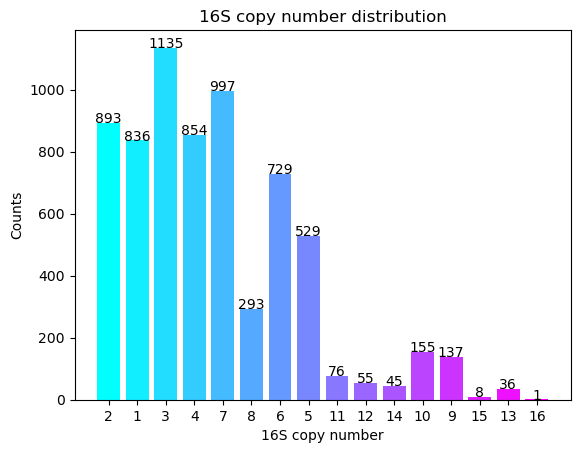

In [4]:
copies_count = {}
for species, copies in mylist:
    if copies in copies_count:
        copies_count[copies] += 1
    else:
        copies_count[copies] = 1

categories = list(copies_count.keys())
counts = list(copies_count.values())

colors = plt.cm.cool(np.linspace(0, 1, len(categories)))
plt.bar(categories, counts, color=colors)

for i, count in enumerate(counts):
    plt.text(categories[i], count + 0.1, str(count), ha='center')
plt.xticks(categories)
plt.xlabel('16S copy number')
plt.ylabel('Counts')
plt.title('16S copy number distribution')
plt.show()

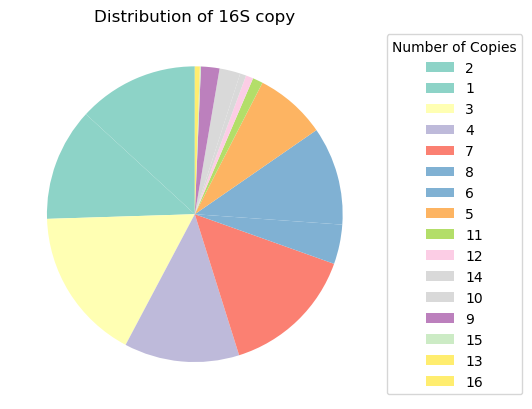

In [5]:

colors = plt.cm.Set3(np.linspace(0, 1, len(categories)))

plt.pie(counts, labels=None, colors=colors, startangle=90)


plt.legend(categories, title='Number of Copies', bbox_to_anchor=(1, 0.5), loc='center left')


plt.title('Distribution of 16S copy')

plt.show()

As we can see from the piechart, the vast majority of species has a copy number lower than 10.

We check for possible duplicates in my data

In [6]:
species_count = [(x,speci.count(x)) for x in speci]


### Hyper-represented species in my data

In [7]:
uniques = list(set([t for t in species_count if t[1] == 1]))

Uniques contain the species present only once in the dataset, while doubles represent the species present  more than once in the dataset

In [8]:
doubles = list(set([t for t in species_count if t[1] > 1]))

In [9]:
unique_species = [t[0] for t in species_count if t[1] ==1]
non_unique_species = set([t[0] for t in species_count if t[1]>1])

In [10]:
print(f'{len(unique_species)} unique species',f'{len(non_unique_species)} non unique species')



3650 unique species 422 non unique species


In [11]:
repetitive_microorg = list(set(non_unique_species))

We do not want in our dataset incoherent signals, i.e., microorganisms belonging to the same species and the same strain having a non-unique value for their 16S copy number

In [12]:
 df = pd.DataFrame(mylist, columns=["Specie", "16S copy number"])

In [13]:
df = df.drop_duplicates().reset_index(drop=True)


In [15]:
x = df[df["Specie"]=="Escherichia coli"]
print(x)

                Specie 16S copy number
2591  Escherichia coli               7
2852  Escherichia coli               6
2853  Escherichia coli               2
2855  Escherichia coli               1
2926  Escherichia coli               8


In [16]:
s = list(df["Specie"])
count = [(x,s.count(x)) for x in s]

In [17]:
incoeher_n = set([t[0] for t in count if t[1] > 1])

In [18]:
df = df[~df['Specie'].isin(incoeher_n)].reset_index(drop=True)


df contains the final set of species present in my dataset, after removing incoherent signals and duplicated microorganisms

### Final dataset 

In [20]:
final_df = df

We replot the 16S copy number distribution after cleaning the dataset

In [22]:
lista_tuple = list(final_df.itertuples(index=False, name=None))

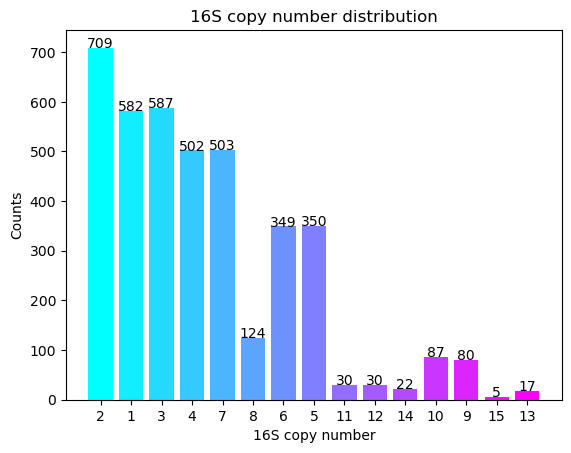

In [23]:
copies_count = {}
for species, copies in lista_tuple :
    if copies in copies_count:
        copies_count[copies] += 1
    else:
        copies_count[copies] = 1

categories = list(copies_count.keys())
counts = list(copies_count.values())

colors = plt.cm.cool(np.linspace(0, 1, len(categories)))
plt.bar(categories, counts, color=colors)

for i, count in enumerate(counts):
    plt.text(categories[i], count + 0.1, str(count), ha='center')
plt.xticks(categories)
plt.xlabel('16S copy number')
plt.ylabel('Counts')
plt.title('16S copy number distribution')
plt.show()

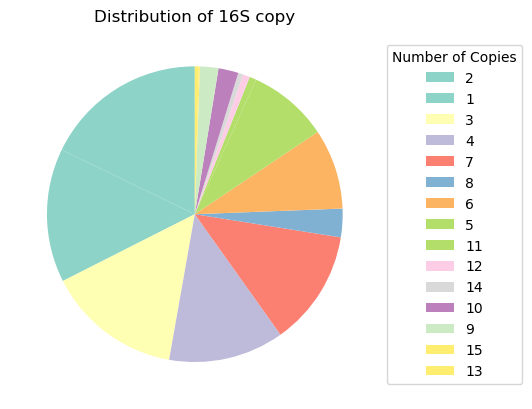

In [24]:
colors = plt.cm.Set3(np.linspace(0, 1, len(categories)))

plt.pie(counts, labels=None, colors=colors, startangle=90)


plt.legend(categories, title='Number of Copies', bbox_to_anchor=(1, 0.5), loc='center left')

plt.title('Distribution of 16S copy')
plt.show()

### Adding the sequences

We filter all the sequences present in SSU 138.1 database (file "SILVASSU.fasta") of 16S sequences given the list of microorganisms which are present
in my final dataset and we save it in a fasta file called "Mysequences.fasta". This is the quickest solution since the SILVA database does not have an API package, unlike the Entrez database, so we download the complete dataset of 16S sequences and we keep only the sequences of species present in my dataset

In [30]:
with open("SILVASSU.fasta","r") as fasta_file,open("Mysequences.fasta","w") as g:
    for record in SeqIO.parse(fasta_file, 'fasta'):
        if record.description.split(";")[-1] in list(final_df["Specie"]) :
            g.write(f">{record.description}\n")
            g.write(f"{record.seq}\n")  
        

### Creation of  my dataframe from sequences in Mysequences.fasta

In [25]:
file_path = 'Mysequences.fasta'
species = []
ID = []
sequences = []
genus = []
family = []
phylum = []
length = []
with open(file_path) as fasta_file:
    for record in SeqIO.parse(fasta_file, 'fasta'):
        ID.append(record.id)
        species.append(record.description.split(";")[-1])
        genus.append(record.description.split(";")[-2])
        family.append(record.description.split(";")[-3])
        phylum.append(record.description.split(";")[1])
        sequences.append(record.seq)
        length.append(len(record.seq))
    n= len(ID)
      

We retain the ID of the sequence, the sequence itself, the species, the genus, the family, the phylum and the length of the sequence

In [26]:
data = {'ID':ID, 'sequence':sequences, 'Specie':species,
        "Genus":genus,"Family":family,"Phylum":phylum,"Length":length}
sequences_data_frame = pd.DataFrame(data)

In [27]:
sequences_data_frame.shape

(93013, 7)

We are left with 93,013 sequences for approximately 4,000 species.

We merge the dataframe containing all the taxonomical info and the sequence and the dataframe containing the name of the organism and the 16S copy number

In [28]:
complete_dataset =pd.merge(sequences_data_frame,final_df, on='Specie', how='inner')


In [29]:
species_in_df = list(set(complete_dataset["Specie"]))

# Data visual analysis

### Visual phylogenetic analysis

#### Phylum distribution in my dataset

In [30]:
conteggio_specie_per_phylum = complete_dataset.groupby('Phylum')['Specie'].nunique()

In [31]:
conteggio_specie_per_phylum = conteggio_specie_per_phylum.sort_values(ascending=False)

<AxesSubplot:xlabel='Phylum'>

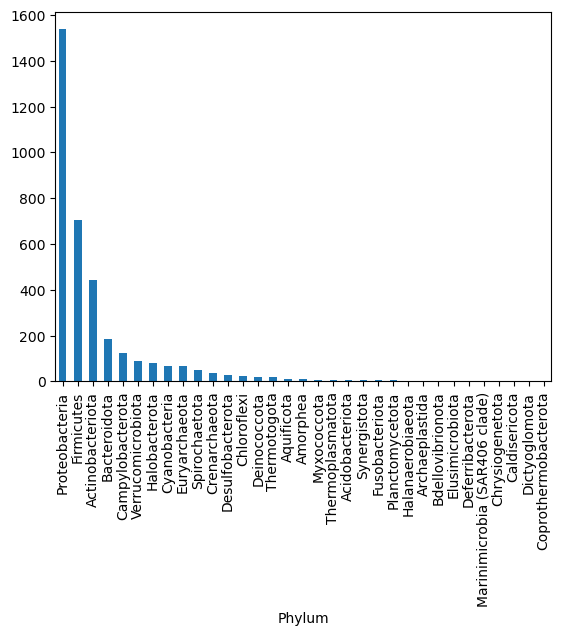

In [32]:
conteggio_specie_per_phylum.plot.bar()

As we can see from the barplot, vast majority of my organisms belong to 4 phyla:
    - Proteobacteria
    - Firmicutes
    - Actinobacteriota
    -Bacteroidata
    

#### Sequence distribution in my dataset


We must assess the amount of sequences for each species in my dataset.

In [33]:
conteggio_ID_per_specie = complete_dataset.groupby('Specie')['ID'].nunique()

In [34]:
df_per_seq_per_specie = complete_dataset[["ID","sequence","Specie"]]

Here we can appreciate how just the 0.42% of the total species have 37% of the all sequences present in the dataset.
it is highly unbalanced and an undesirable situation

In [35]:
conteggio_ID_per_specie= conteggio_ID_per_specie.sort_values(ascending=False)
conteggio_ID_per_specie.head(15)

Specie
Klebsiella pneumoniae           5473
Pseudomonas aeruginosa          4827
Mycobacterium tuberculosis      3798
Bacillus licheniformis          2683
Bacillus pumilus                2197
Lactococcus lactis              2196
Enterobacter cloacae            2057
Enterococcus faecalis           1864
Salmonella enterica             1803
Stenotrophomonas maltophilia    1516
Streptococcus suis              1474
Serratia marcescens             1315
Enterococcus durans             1279
Leuconostoc mesenteroides       1170
Haemophilus influenzae          1044
Name: ID, dtype: int64

In [36]:
df_sequenze = pd.DataFrame({'specie': conteggio_ID_per_specie.index, 'number of sequences': conteggio_ID_per_specie.values})


#### Boxplot representing the number of sequences per specie in the dataset

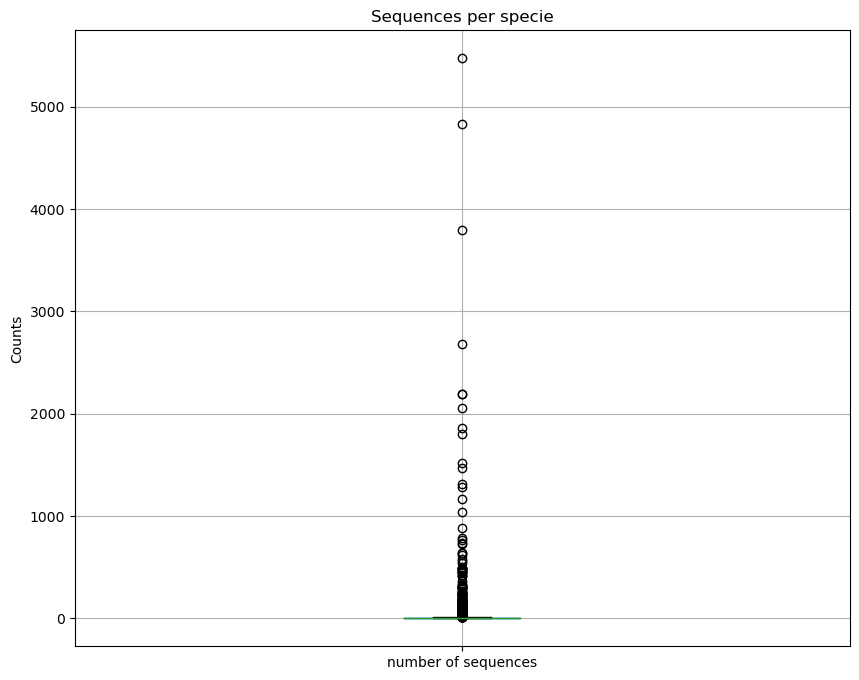

In [37]:
plt.figure(figsize=(10, 8))
df_sequenze.boxplot(column='number of sequences',showfliers=True)
plt.title('Sequences per specie')
plt.ylabel('Counts')
plt.show()

We plot it after  removing  outliers

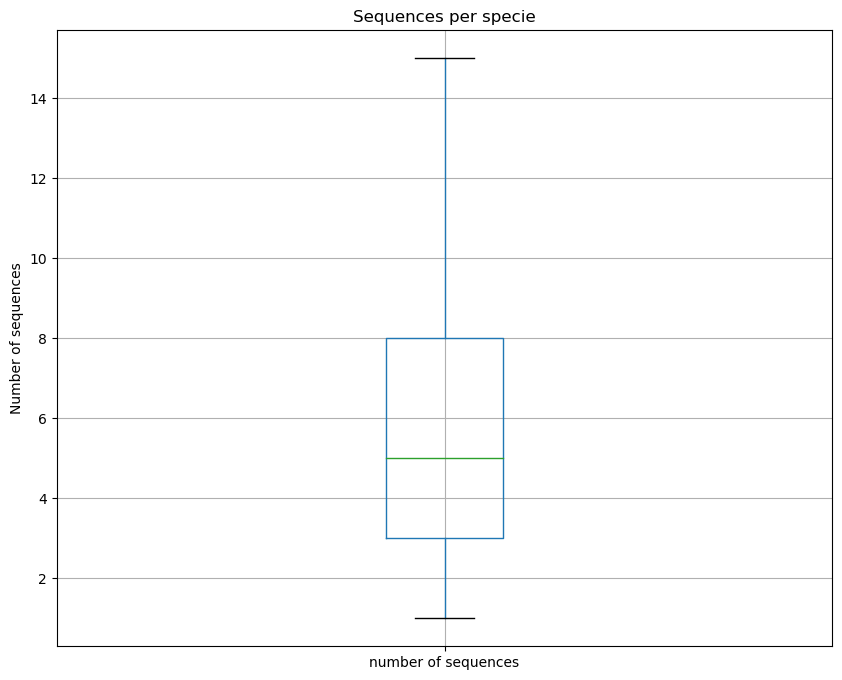

In [38]:
plt.figure(figsize=(10, 8))
df_sequenze.boxplot(column='number of sequences',showfliers=False)
plt.title('Sequences per specie')
plt.ylabel('Number of sequences')
plt.show()

Without outliers, the number of sequences per species is more homogenous in my dataset.

In [39]:
conteggio_ID_per_specie= conteggio_ID_per_specie.sort_values(ascending=False)

In [40]:
l = []
for i in range(0,len(conteggio_ID_per_specie)):
    if conteggio_ID_per_specie[i] > 5000:
        l.append("M")
    elif conteggio_ID_per_specie[i] > 3000:
        l.append("L")
    elif conteggio_ID_per_specie[i] > 2000:
        l.append("K")
    elif conteggio_ID_per_specie[i] > 1000:
        l.append("J")
    elif conteggio_ID_per_specie[i] > 500:
        l.append("I")
    elif conteggio_ID_per_specie[i] > 250:
        l.append("H")
    elif conteggio_ID_per_specie[i] > 100:
        l.append("G")
    elif conteggio_ID_per_specie[i] > 50:
        l.append("F")
    elif conteggio_ID_per_specie[i] > 20:
        l.append("E")
    elif conteggio_ID_per_specie[i] > 8:
        l.append("D")
    elif conteggio_ID_per_specie[i] > 5:
        l.append("C")
    elif conteggio_ID_per_specie[i] > 3:
        l.append("B")
    else:
        l.append("A")
        

In [41]:
df_sequenze["cat_length"]= l

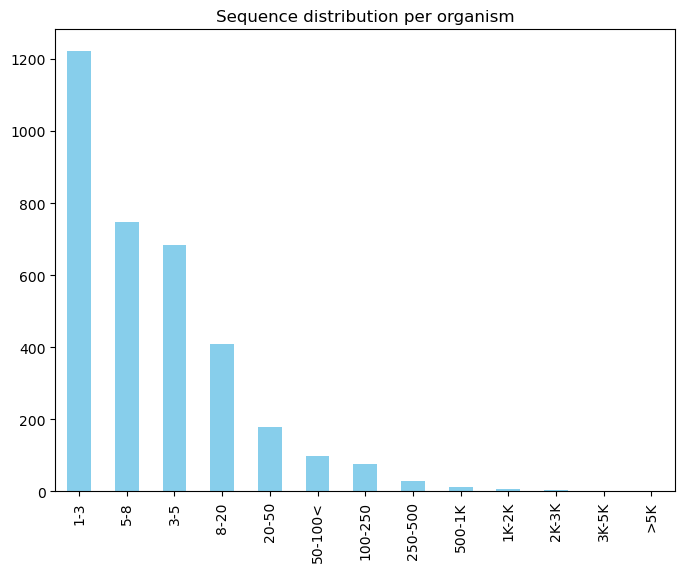

In [42]:
conteggio_categorie = df_sequenze['cat_length'].value_counts()
plt.figure(figsize=(8, 6))
conteggio_categorie.plot(kind='bar', color='skyblue')


ticks_posizioni = [0, 1, 2, 3, 4, 5, 6, 7, 8,9,10,11,12]
ticks_etichette = ['1-3', '5-8', '3-5', '8-20', '20-50', '50-100<', '100-250', '250-500', '500-1K', '1K-2K','2K-3K',"3K-5K",">5K"]
plt.xticks(ticks_posizioni, ticks_etichette)
plt.title('Sequence distribution per organism')
plt.show()

As we can see from this barplot the dataset is highly imbalanced; the vast majority of species has a number of sequences between 1 and 20,while there are some hyper represented species with more than one thousand sequences per species.
This result is undesirable. 

#### Sequence length distribution in the dataset

In [43]:
lunghezza_media_per_specie = complete_dataset.groupby('Specie')['Length'].mean()
median_length = complete_dataset['Length'].median()
mean_length = complete_dataset['Length'].mean()


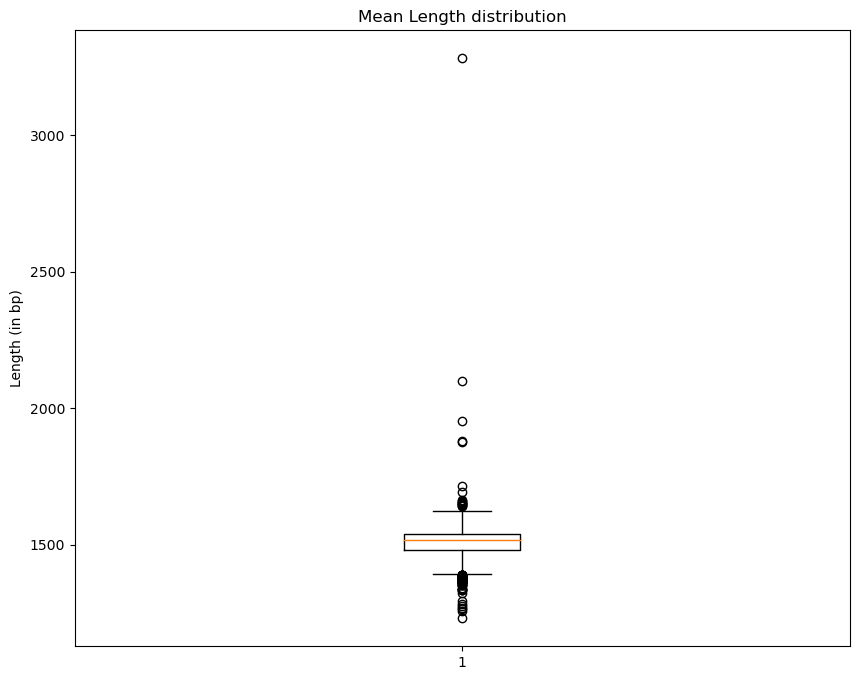

In [44]:
plt.figure(figsize=(10, 8))
plt.boxplot(lunghezza_media_per_specie)
plt.title('Mean Length distribution')
plt.ylabel('Length (in bp)')
plt.show()

We remove outliers

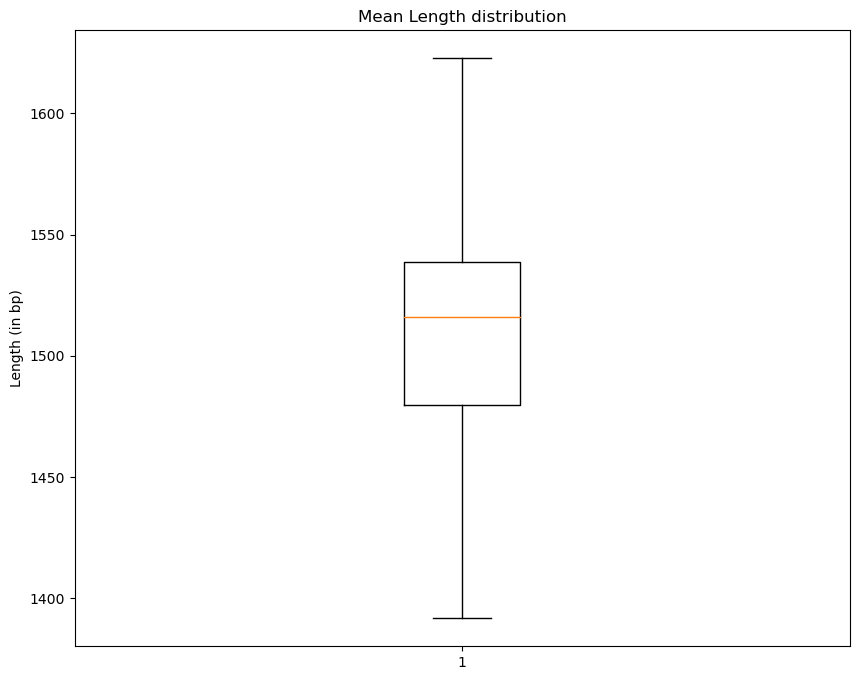

In [45]:
plt.figure(figsize=(10, 8))
plt.boxplot(lunghezza_media_per_specie,showfliers=False)
plt.title('Mean Length distribution')
plt.ylabel('Length (in bp)')
plt.show()

#### Subsampling of my sequences

Due to the vast heterogeneity of the number of sequences per species, where we have species with more than 1000 sequences when the
median value is around 5, we need to subsample more abundant sequences.
The sub-sampling was also applied to reduce the computational burden of the analysis.

In [46]:
thresh = 5
over_repr_species = list(df_sequenze.loc[df_sequenze["number of sequences"]> thresh]["specie"])
fairly_repr_species =list(df_sequenze.loc[df_sequenze["number of sequences"]<= thresh]["specie"])

In [47]:
over_represented_rows = complete_dataset[complete_dataset['Specie'].isin(over_repr_species)]
over_represented_rows.shape

(87432, 8)

Given a species,if you have more sequences than the threshold, we subsample exactly threshold sequences, while if you have less sequences than threshold we do not perform subsampling 

In [48]:
sampled_ids_list = []


for name, group in over_represented_rows.groupby('Specie'):
    if len(group) >= thresh:
        sampled_ids_list.extend(group['ID'].sample(thresh).tolist())
    else:
        sampled_ids_list.extend(group['ID'].tolist())


In [49]:
true_5_members = int(len(sampled_ids_list)/5)

In [50]:
print(f'there are {true_5_members} species that have more than 5 sequences and are sampled to have exactly 5 sequences')

there are 1561 species that have more than 5 sequences and are sampled to have exactly 5 sequences


In [51]:
risultato_filtro = complete_dataset[complete_dataset['Specie'].isin(fairly_repr_species)]
risultato_filtro.shape

(5581, 8)

In [52]:
sampled_rows = complete_dataset[complete_dataset['ID'].isin(sampled_ids_list)]


In [53]:
definitive_version = pd.concat([risultato_filtro,sampled_rows])

In [54]:
definitive_version.shape

(13386, 8)

## Hierarchical clustering

We compute each pairwise distance between sequences employing the Levenshtein distance, which is more suitable than Hamming distance
for computing distances among sequences of different lengths.

The Levenshtein distance between two words is the minimum number of single-character edits (insertions, deletions or substitutions) required to change one sequence into the other.

We will use the matrix of the distances between sequences to perform Hierarchical clustering.

In [ ]:
n = len(definitive_version["sequence"])
dist_matrix = [[0] * n for _ in range(n)]
for i in range(n):
    for j in range(n):
        dist_matrix[i][j] = distance(definitive_version.iloc[i]['sequence'], definitive_version.iloc[j]['sequence'])


The matrix is not symmetric since it is computed in an optimized way but in order to use it for clustering and classification
tasks it needs to be modified in the form of a squared matrix.
In actual fact, I computed the matrix using a parallel programming approach to speed up the computation time and I saved its output into a file in order to compute it just once and then I used it when needed without recomputing it each time

In [56]:
dist_vector = np.load("dist_matrix_13386.npz")["d"]

dist_vector is a vector and i need to convert it into square matrix

In [57]:
n = 13386
index = 0
dist_matrix = np.zeros((n,n))
for row in range(0,n):
    for col in range(row+1,n):
        dist_matrix[col,row] = dist_vector[index]
        dist_matrix[row,col] = dist_vector[index]
        index = index+1


I recover the IDs of sequenced employed to compute the distance matrix

In [58]:
l= []
with open("lista_IDs_13386.txt") as f:
    for line in f:
        ID = line.strip("\n")
        l.append(ID)
        

I access rows of the dataset based on the IDs contained in the list 

In [59]:

df_dist = complete_dataset.loc[complete_dataset['ID'].isin(l)]
df_copy = df_dist.copy()

I want to find all the species that have only one sequence associated to them, since they are the "True" 1 member clusters

In [60]:
one_seq_ids =df_dist.groupby('Specie').filter(lambda x: len(x) == 1)["ID"]

In [61]:
one_seq_ids.shape
print(f'there are {one_seq_ids.shape[0]} species that are associated to only one sequence')

there are 306 species that are associated to only one sequence


I decided to employ a simple Hierarchical clustering algorithm because it works with non-euclidean distances and I can tune the desired
number of clusters based on the number of species present in the dataset.

## Simple agglomerative hierarchical clustering

Since I know how many species are present in my dataset, I would like to obtain the number of clusters equal to the number of species in my dataset.
We would like also to obtain that the partition of my data made by the cluster algorithm is coherent with the different species present  in the dataset

In [62]:
hierarchical_cluster = AgglomerativeClustering(n_clusters=3465,affinity='precomputed', 
    linkage='average')

In [63]:
clusters = hierarchical_cluster.fit_predict(dist_matrix)

C:\Simone\anaconda3\lib\site-packages\sklearn\cluster\_agglomerative.py:983: FutureWarning: Attribute `affinity` was deprecated in version 1.2 and will be removed in 1.4. Use `metric` instead
  warnings.warn(


In [64]:
df_dist['Cluster'] = clusters

C:\Users\Simone\AppData\Local\Temp\ipykernel_20848\3217638405.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dist['Cluster'] = clusters


I access the rows of the one sequence member elements of the dataset

In [65]:
one_seq_df = df_dist[df_dist["ID"].isin(one_seq_ids)].reset_index(drop=True)

As expected, this dataframe has 306 rows, which is also the length of the list of the species that have only one sequence

Now we have to recover all the rows that are associated to the clusters of species that have only one sequence

In [66]:
clus_idxs = one_seq_df["Cluster"].tolist()

In [67]:
uniq_clus = df_dist[df_dist["Cluster"].isin(clus_idxs)]

In [68]:
one_seq_clus = uniq_clus.groupby("Cluster").filter(lambda x: len(x) == 1)
print(f'there are {one_seq_clus.shape[0]} clusters correctly made of only one member out of 306 true one member clusters')

there are 40 clusters correctly made of only one member out of 306 true one member clusters


We can appreciate how the clustering algorithm has correctly clustered in one member cluster only the 10% of actual species that
had only one sequence associated to them

### Species composition of each cluster

We analyze the specie composition of each cluster

In [69]:
species_per_cluster = df_dist.groupby('Cluster')['Specie'].nunique()


In [70]:
species_per_clust_entropy = df_dist.groupby('Cluster')['Specie']

For each cluster we compute the Shannon entropy as a measure of homogeneity inside my clusters.
$$
\ S = -\sum_{i} \log_2(f_i) \cdot f_i
$$
where fi represents the relative frequency of each specie inside a cluster.


If a cluster is made of only one specie the entropy will be equal to 0, while it increases with the number of different species
present inside a cluster.

In [71]:
entropy_list = []
one_seq_clus = 0
zero_entropy_more_than_one = 0
for el in species_per_clust_entropy:
    count = el[1].value_counts(normalize=True)
    if len(el[1]) == 1:
        E = 0
        one_seq_clus = one_seq_clus+1
        entropy_list.append(E)
    else:
        E = -sum(np.log2(count)*count)
        if E == -0.0:
            E = 0
            zero_entropy_more_than_one= zero_entropy_more_than_one+1
            entropy_list.append(E)
        else:
            entropy_list.append(E)
        
    
    

In [72]:
print(f'there are {zero_entropy_more_than_one} clusters that have 0 entropy but they are made of more than one sequence,while there are {one_seq_clus} that have 0 entropy and only one sequence')

there are 609 clusters that have 0 entropy but they are made of more than one sequence,while there are 1724 that have 0 entropy and only one sequence


Based on this data and the number of truly one member clusters identified, we can state that the vast majority of these one member
clusters are formed by species who were associated to more than one sequence. So for these species the intra-specie similarity of
16S sequences is not sufficient to implement (with this data) an accurate KNN classifier for predicting the  16S copy number.

#### Entropy distribution

Text(0.5, 1.0, 'Entropy of each cluster')

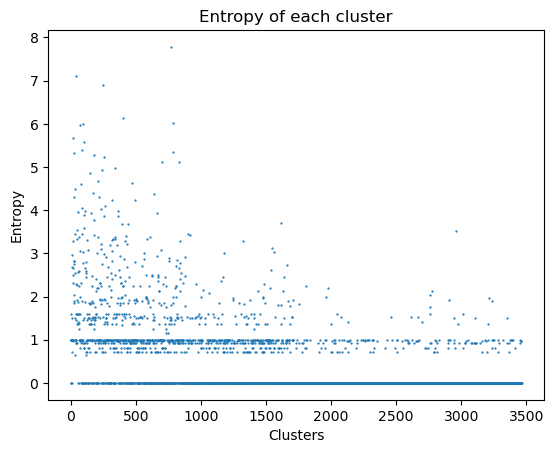

In [73]:
plt.plot(range(len(entropy_list)), entropy_list, 'o',markersize=0.6)

plt.xlabel('Clusters')
plt.ylabel('Entropy')
plt.title('Entropy of each cluster')

From the plot we can notice that the vast majority of clusters have entropy values between 0 and 1, but with a significant portion
has higher values.
There are also few clusters which have very high values of Entropy (>6)

In [74]:
print("there are 1132 clusters which have an Entropy greater than 0 and more than one sequence per cluster")

there are 1132 clusters which have an Entropy greater than 0 and more than one sequence per cluster


These are the clusters where we have more than one species and for these sequences it is not true that sequences coming from the same species have a Levensthein distance which is lower compared to sequences coming from different microorganisms

We evaluate not only the specie composition of each cluster, but also the Genus composition of each cluster.
Maybe our algorithm did not group together sequences belonging to the same species but it could group sequences of the same Genus.

In [75]:
genus_per_clust_entropy = df_dist.groupby('Cluster')['Genus']

In [76]:
entropy_list_genus = []
one_seq_clus_genus = 0
zero_entropy_more_than_one_genus = 0
for el in genus_per_clust_entropy:
    count = el[1].value_counts(normalize=True)
    if len(el[1]) == 1:
        E = 0
        one_seq_clus_genus = one_seq_clus_genus+1
        entropy_list_genus.append(E)
    else:
        E = -sum(np.log2(count)*count)
        if E == -0.0:
            E = 0
            zero_entropy_more_than_one_genus= zero_entropy_more_than_one_genus+1
            entropy_list_genus.append(E)
        else:
            entropy_list_genus.append(E)
        

### Genus Composition 

Text(0.5, 1.0, 'Entropy of each cluster based on Genus composition')

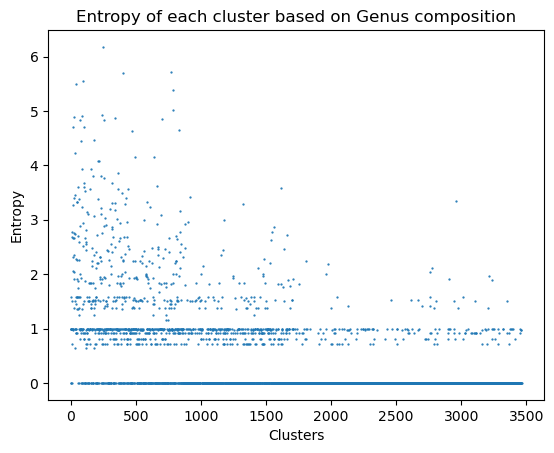

In [77]:
plt.plot(range(len(entropy_list_genus)), entropy_list_genus, 'o',markersize=0.6)

plt.xlabel('Clusters')
plt.ylabel('Entropy')
plt.title('Entropy of each cluster based on Genus composition')

We still have lot of clusters with entropy values higher than 2, but we do not have more outliers (no entropy values > 6)

In [78]:
print(f'there are {zero_entropy_more_than_one_genus} clusters that have 0 entropy but they are made of more than one sequence')

there are 619 clusters that have 0 entropy but they are made of more than one sequence


We can appreciate that looking at the Entropy of the clusters based on the Genus results in an increase of only 10 clusters made
of more than one sequence and 0 entropy

We evaluate entropy of each cluster based on family composition

In [79]:
family_per_clust_entropy = df_dist.groupby('Cluster')['Family']


In [80]:
entropy_list_fam = []
one_seq_clus_fam = 0
zero_entropy_more_than_one_fam = 0
for el in family_per_clust_entropy:
    count = el[1].value_counts(normalize=True)
    if len(el[1]) == 1:
        E = 0
        one_seq_clus_fam = one_seq_clus_fam+1
        entropy_list_fam.append(E)
    else:
        E = -sum(np.log2(count)*count)
        if E == -0.0:
            E = 0
            zero_entropy_more_than_one_fam= zero_entropy_more_than_one_fam+1
            entropy_list_fam.append(E)
        else:
            entropy_list_fam.append(E)
        

In [81]:
print(f'there are {zero_entropy_more_than_one_fam} clusters that have 0 entropy but they are made of more than one sequence')

there are 627 clusters that have 0 entropy but they are made of more than one sequence


Again we observe just a small increase of the number of clusters made of more than one sequence that have 0 Entropy based on family
composition of each cluster.

So we can state that the Hierarchical clustering algorithm applied to the sequences data is not able to capture the phylogenetic
suddivion in our data

### Numerosity Analysis of the clusters

We want to analyze the numerosity distribution of the clusters obtained with the classical implementation of the Hierarchical clustering

In [82]:
members_per_clust = df_dist.groupby('Cluster').size()

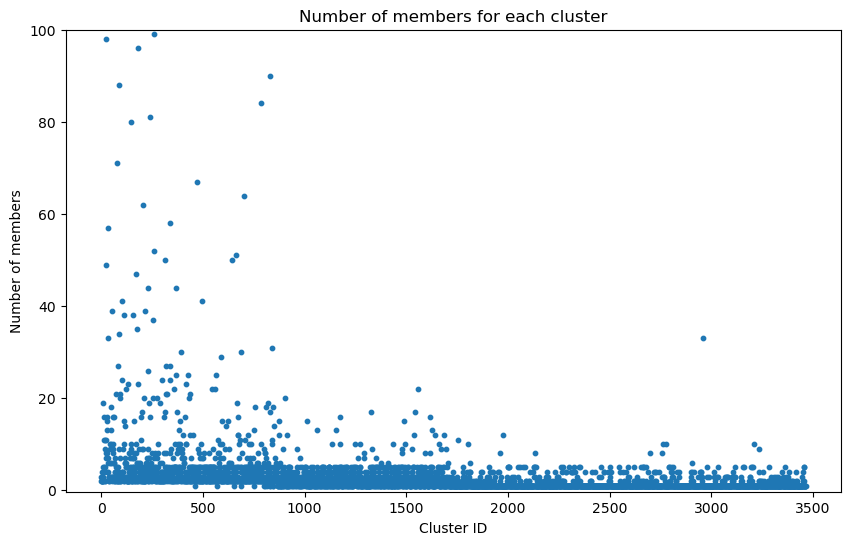

In [83]:
plt.figure(figsize=(10, 6))
plt.scatter(members_per_clust.index, members_per_clust,s=10)
plt.ylim(-0.3,100)
plt.xlabel('Cluster ID')
plt.ylabel('Number of members')
plt.title('Number of members for each cluster')
plt.show()

From this plot is pretty clear that the vast majority of clusters has a numerosity in the range 1 to 10, but there is a significant
fraction of clusters that has very extreme values, in some cases a single cluster has more than 50 members.We can then notice a
very significant portion of clusters made of only one member(one sequence).

We want to analyze the relationship between Entropy values and cluster numerosity

In [86]:
data = {"cluster_id":range(0,len(entropy_list)),"Entropy":entropy_list,"number_of_members":members_per_clust}
df = pd.DataFrame(data)

In [87]:
true_5_members = df[(df["Entropy"]==0) & (df["number_of_members"]==5)]
true_5_members.shape[0]

22

The classical implementation of Hierarchical clustering is able to correctly clusterize the sequences of just 22 out of 1561 species
that have exactly 5 sequences

Text(0.5, 1.0, 'Cluster ID vs Number of  Members')

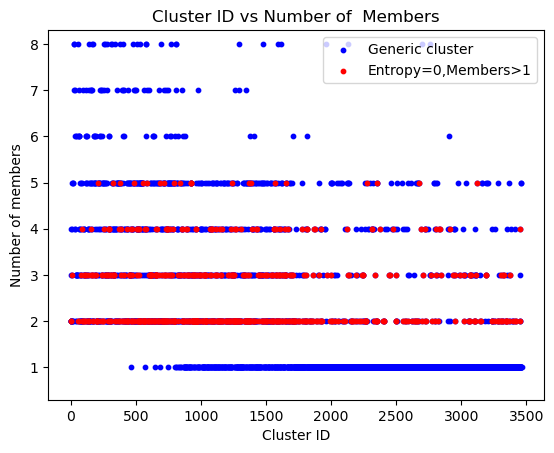

In [88]:
filtered_clusters = df[(df['Entropy'] == 0) & (df['number_of_members'] > 1)]
plt.scatter(df['cluster_id'], df['number_of_members'], color='blue', label='Generic cluster',s=10)
plt.scatter(filtered_clusters['cluster_id'], filtered_clusters['number_of_members'], color='red', label='Entropy=0,Members>1',s=10)


plt.xlabel('Cluster ID')
plt.ylim(0.3,8.3)
plt.ylabel('Number of members')


plt.legend()


plt.title('Cluster ID vs Number of  Members')

This plot represents in red clusters that have more than one sequence and 0 entropy; as we can notice we do not find clusters with 0 Entropy when we exceed 5 members.

This effect is somehow articial since it is caused by the subsampling procedure applied to the sequence dataset. The sequence dataset was highly disbalanced, with vast majority of species bearing a number of sequence not greater than 10, butt some outliers with extreme values were present.

For this reason, we subsampled 5 sequences per specie if their number exceed a threshold,which was set to 5. In this way the maximum number of sequences per specie is 5, and consequentionally for this reason we do not find clusters with entropy equal to 0 made of 6 or more members

### Hierarchical Clustering with Genie module

genieclust is an open source Python and R package that implements the hierarchical clustering
algorithm called Genie. This method frequently outperforms other state-of-the-art approaches in terms
of clustering quality and speed, supports various distances over dense, sparse, and string data domains,
and can be robustified even further with the built-in noise point detector.Genie is a multi-purpose hierarchical clustering algorithm based on the following intuitive idea. First, make
each individual point the sole member of its own cluster. Then,
seek and merge the pairs of the closest clusters, one after another,
applying the single linkage criterion except where the Gini index
of the cluster size distribution raises above a predefined threshold.
It only requires some similarity measure
between a pair of observations. With genieclust, partitioning
can be performed for dense, sparse, and string data as well as with
various metrics, including the Euclidean, Manhattan, cosine, and
Levenshtein ones. It also allows for the extraction of any number
of clusters(Marek Gagolewski,
genieclust: Fast and robust hierarchical clustering,
SoftwareX,
Volume 15,
2021,
100722,
ISSN 2352-7110,
https://doi.org/10.1016/j.softx.2021.100722.
(https://www.sciencedirect.com/science/article/pii/S2352711021000649))

In [90]:
hier = genieclust.Genie(n_clusters=3465,gini_threshold=0.3, M=1, affinity='precomputed', exact=True)

In [91]:
hier.fit(dist_matrix, y=None)

Genie(affinity='precomputed', n_clusters=3465)

In [92]:
pred_clus = hier.labels_

In [93]:
df_copy['Cluster'] = pred_clus

In [94]:
one_seq_df_g = df_copy[df_copy["ID"].isin(one_seq_ids)].reset_index(drop=True)

Now we have to recover all the rows that are associated to the clusters of species that have only one specie

In [95]:
clus_idxs_g = one_seq_df_g["Cluster"].tolist()

In [96]:
uniq_clus_g = df_copy[df_copy["Cluster"].isin(clus_idxs_g)]

In [97]:
one_seq_clus_g = uniq_clus_g.groupby("Cluster").filter(lambda x: len(x) == 1)
print(f'there are {one_seq_clus_g.shape[0]} clusters correctly made of only one member out of 306 true one member clusters')

there are 1 clusters correctly made of only one member out of 306 true one member clusters


We were able to identify only one true one member cluster out of more than 300. We will see that this is a feature due to the Genie
algorithm implementation

### Entropy Analysis

In [98]:
species_per_cluster_g = df_copy.groupby('Cluster')['Specie']

We analyze the specie composition of each cluster,using again the Shannon Entropy as measure of cluster homogeneity in terms of species composition

In [99]:
entropy_list_g = []
one_seq_clus_g = 0
zero_entropy_more_than_one_g = 0
for el in species_per_cluster_g:
    count = el[1].value_counts(normalize=True)
    if len(el[1]) == 1:
        E = 0
        one_seq_clus_g = one_seq_clus_g+1
        entropy_list_g.append(E)
    else:
        E = -sum(np.log2(count)*count)
        if E == -0.0:
            E = 0
            zero_entropy_more_than_one_g= zero_entropy_more_than_one_g+1
            entropy_list_g.append(E)
        else:
            entropy_list_g.append(E)
        

In [100]:
print(f'there are {zero_entropy_more_than_one_g} clusters that have 0 entropy but they are made of more than one sequence,while there are {one_seq_clus_g} that have 0 entropy and only one sequence')

there are 979 clusters that have 0 entropy but they are made of more than one sequence,while there are 84 that have 0 entropy and only one sequence


Based on this data and the number of truly one member clusters identified, we can see how the Genie algorithm significantly 
identified less true one member clusters compared to the classical implementation of the algorithm.
However, it does not  over-represents this class of one member clusters as done by the classical implementation of hierarchical 
clustering (84 one member clusters identified vs 1724), keeping in mind that the true number of 1 member cluster should be 306

Text(0.5, 1.0, 'Entropy of each cluster')

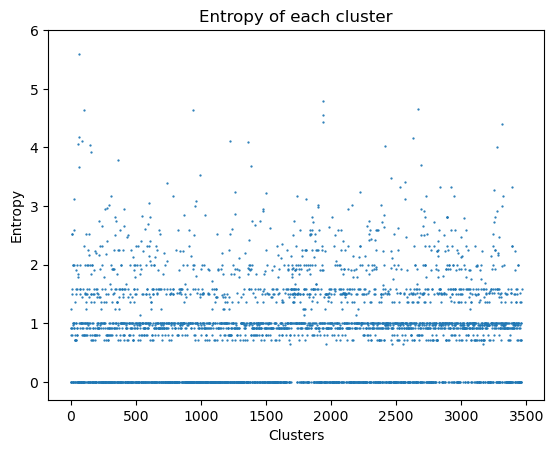

In [101]:
plt.plot(range(len(entropy_list_g)), entropy_list_g, 'o',markersize=0.6)
plt.ylim(-0.3,6)
plt.xlabel('Clusters')
plt.ylabel('Entropy')
plt.title('Entropy of each cluster')

Compared to the classical implementation of the Hierarchical clustering algorithm, we obtained less extreme values of entropy.

In [102]:
print("there are 2402 clusters which have 0 entropy but are made of more than one sequence")

there are 2402 clusters which have 0 entropy but are made of more than one sequence


These are the clusters where we have more than one specie and for these sequences it is not true that sequences coming from the same specie have a Levensthein distance which is lower compared to sequences coming from different microorganisms


We look at Entropy of each cluster based on Genus

In [103]:
genus_per_clust_entropy_g = df_copy.groupby('Cluster')['Genus']

In [104]:
entropy_list_g_g = []
one_seq_clus_g_g = 0
zero_entropy_more_than_one_g_g = 0
for el in genus_per_clust_entropy_g:
    count = el[1].value_counts(normalize=True)
    if len(el[1]) == 1:
        E = 0
        one_seq_clus_g_g = one_seq_clus_g_g+1
        entropy_list_g_g.append(E)
    else:
        E = -sum(np.log2(count)*count)
        if E == -0.0:
            E = 0
            zero_entropy_more_than_one_g_g= zero_entropy_more_than_one_g_g+1
            entropy_list_g_g.append(E)
        else:
            entropy_list_g_g.append(E)
        

### Genus composition

Text(0.5, 1.0, 'Entropy of each cluster based on Genus composition')

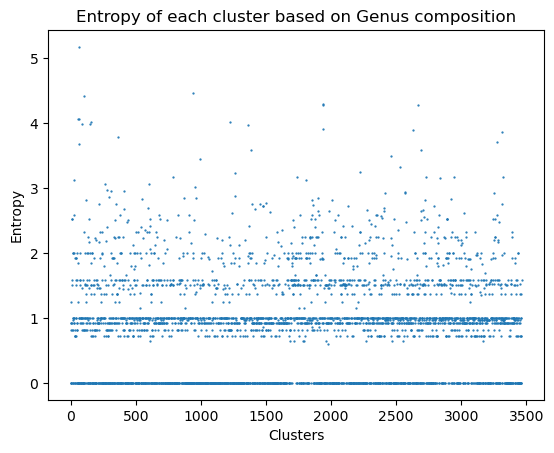

In [105]:
plt.plot(range(len(entropy_list_g_g)), entropy_list_g_g, 'o',markersize=0.6)

plt.xlabel('Clusters')
plt.ylabel('Entropy')
plt.title('Entropy of each cluster based on Genus composition')

In [106]:
print(f'there are {zero_entropy_more_than_one_g_g} clusters that have 0 entropy but they are made of more than one sequence')

there are 1016 clusters that have 0 entropy but they are made of more than one sequence


We observe a small increase in the number of clusters made of more than one sequence that have 0 entropy based on Genus composition
of each cluster

We evaluate entropy of each cluster based on family composition

In [107]:
family_per_clust_entropy_g = df_copy.groupby('Cluster')['Family']

In [108]:
entropy_list_fam_g = []
one_seq_clus_fam_g = 0
zero_entropy_more_than_one_fam_g = 0
for el in family_per_clust_entropy_g:
    count = el[1].value_counts(normalize=True)
    if len(el[1]) == 1:
        E = 0
        one_seq_clus_fam_g = one_seq_clus_fam_g+1
        entropy_list_fam_g.append(E)
    else:
        E = -sum(np.log2(count)*count)
        if E == -0.0:
            E = 0
            zero_entropy_more_than_one_fam_g= zero_entropy_more_than_one_fam_g+1
            entropy_list_fam_g.append(E)
        else:
            entropy_list_fam_g.append(E)

In [109]:
print(f'there are {zero_entropy_more_than_one_fam_g} clusters that have 0 entropy but they are made of more than one sequence')

there are 1038 clusters that have 0 entropy but they are made of more than one sequence


We observe a small increase in the number of clusters made of more than one sequence that have 0 entropy based on family composition of each cluster
We can say that the clustering algorithm was not able to capture the family suddivision of species in my dataset.

### Numerosity distribution

In [110]:
members_per_clust_g = df_copy.groupby('Cluster').size()

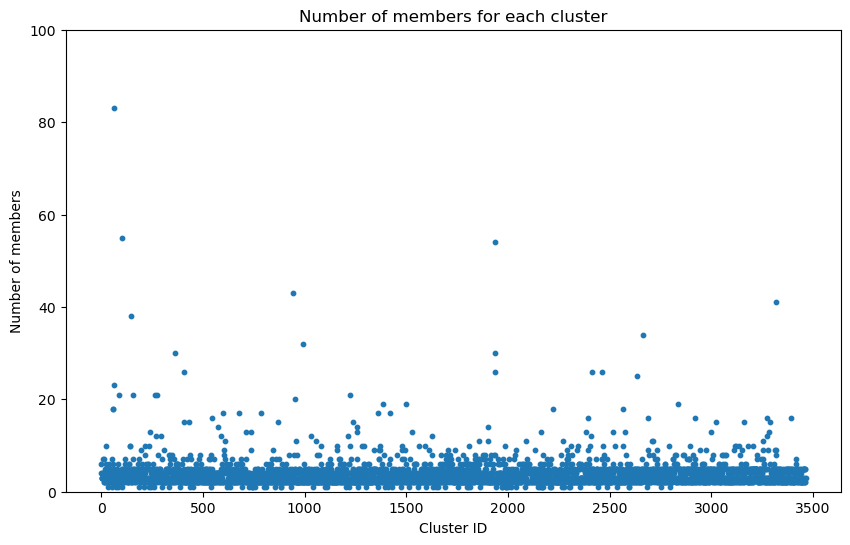

In [111]:
plt.figure(figsize=(10, 6))
plt.scatter(members_per_clust_g.index, members_per_clust_g,s=10)
plt.ylim(0,100)
plt.xlabel('Cluster ID')
plt.ylabel('Number of members')
plt.title('Number of members for each cluster')
plt.show()

We observe that we have less extreme values of number of members for each cluster compared to the classical implementation
of Hierarchical clustering

In [114]:
data = {"cluster_id":range(0,len(entropy_list)),"Entropy":entropy_list_g,"number_of_members":members_per_clust_g}
df_g = pd.DataFrame(data)


In [115]:
true_5_members = df_g[(df_g["Entropy"]==0) & (df_g["number_of_members"]==5)]
true_5_members.shape[0]

41

The Genie implementation of Hierarchical clustering is able to correctly clusterize the sequences of just 41 out of 1561 species that have exactly 5 sequences

Text(0.5, 1.0, 'Cluster ID vs Number of Members')

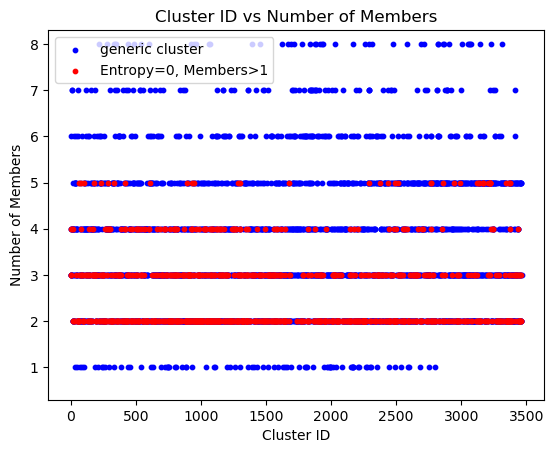

In [117]:
filtered_clusters = df_g[(df_g['Entropy'] == 0) & (df_g['number_of_members'] > 1)]

plt.scatter(df_g['cluster_id'], df_g['number_of_members'], color='blue', label='generic cluster',s=10)
plt.scatter(filtered_clusters['cluster_id'], filtered_clusters['number_of_members'], color='red', label='Entropy=0, Members>1',s=10)

plt.xlabel('Cluster ID')
plt.ylim(0.3,8.3)
plt.ylabel('Number of Members')
plt.legend()


plt.title('Cluster ID vs Number of Members')

We perform a Mann-Whitneyu test to assess if one clustering algorithm has better performance of the other in terms of entropy values of the clusters

In [119]:
statistiche_t, p_valore = mannwhitneyu(entropy_list_g,entropy_list, alternative='greater')


print(f'Statistiche t:{statistiche_t}, p-value: {p_valore}')

if p_valore < 0.05:
    print("Il primo gruppo è significativamente maggiore del secondo gruppo.")
else:
    print("Non c'è evidenza statistica che il primo gruppo sia significativamente maggiore del secondo gruppo.")

Statistiche t:8207018.5, p-value: 1.682249209150436e-175
Il primo gruppo è significativamente maggiore del secondo gruppo.


From the Mann-Whitney test, it looks like that the best clustering algorithm is the classic implementation of Hierarchical clustering
because it has significantly lower values of the Shannon Entropy of each cluster.
But this is due to the fact that we have lot of one sequence cluster, which have by definition 0 entropy.

However using the Genie package for clustering results in an higher number of clusters (979 vs 609) which have 0 Entropy but have more than one sequence.This is balanced by the reduction of the number of
clusters with only one sequence(84 with Genie, 1724 with the classical implementation).

Also the max values of Shannon entropy are affected by the clustering algorithm.
With the classical approach, we have outliers with more extreme values of Entropy(6,7 or even 8), while the outliers obtained with
the Genie algorithm are less extreme.

These effects are due to the implementation of Genie algorithm, since it corrects for highly imbalanced clusters by matching a point
group of the smallest size with its nearest neighbour.
For these reasons we find less one member clusters and less extreme values of entropy or cluster numerosity using the Genie module.

In this particolar setting, where the dataset is more or less homogenous in terms of number of sequences, is preferable the Genie algorithm.


## KNN Classifier

We try to implement a naive KNN classifier to predict the 16S copy number based on similarity of sequences of microorganisms
with a known number of 16S gene.

To compute distances between DNA sequences of 16S gene we use the Levensthein distance

This idea is based on the fact that the 16S copy number tends to be conserved in phylogenetic close species and the 16S gene is 
used as marker gene to build phylogenetic trees since it is an essential ubiquitous gene found in all microorganisms and 
it has hypervariable regions that can help build these phylogenetic trees.

Louca et al also showed that the available tools for predicting 16S copy number have a good accuracy only when the phylogenetic
divergence of the sequence from known sequences is lower than 15%.

In [121]:
df_dist["16S copy number"] = df_dist['16S copy number'].astype('category')

C:\Users\Simone\AppData\Local\Temp\ipykernel_20848\633784269.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dist["16S copy number"] = df_dist['16S copy number'].astype('category')


In [122]:
y = df_dist["16S copy number"]
X = df_dist["sequence"]

In [123]:
X = [str(seq) for seq in X]

We want to see how the performance of the classifier changes when we change the number of neighbours used to predict the 
16S gene copy number.

In [125]:
acc = []
for i in range(1,50):
    model = KNeighborsClassifier(n_neighbors=i, metric='precomputed')
    model.fit(dist_matrix, y)
    predictions = model.predict(dist_matrix)
    accuracy_knn = sum(predictions==y)/len(y)
    acc.append(accuracy_knn)
    misclass_knn = 1 - accuracy_knn
   



#### Accuracy vs number of neighbours

Text(0.5, 1.0, 'Accuracy vs number of neighbors')

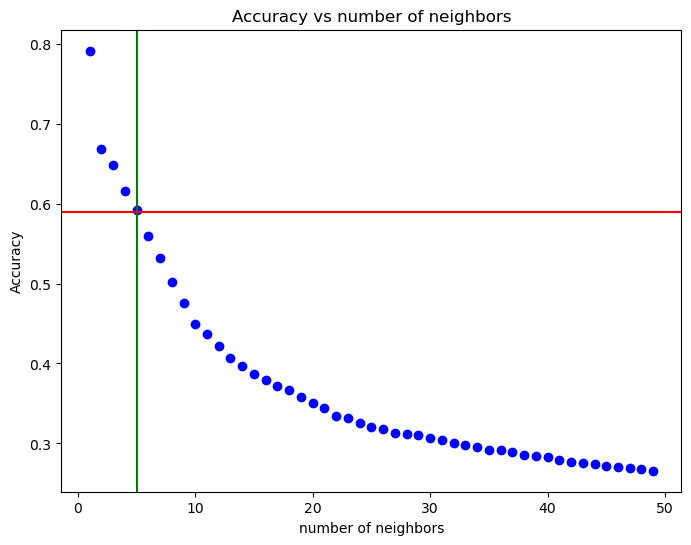

In [126]:
x = range(1,50)
y = np.array(acc)
plt.figure(figsize=(8, 6)) 
plt.scatter(x, y, color='blue', label='Punti') 
plt.axvline(x=5, color="green", linestyle="-", linewidth=1.5)
plt.axhline(y=0.59, color="red", linestyle="-", linewidth=1.5)
plt.xlabel('number of neighbors')
plt.ylabel('Accuracy')
plt.title('Accuracy vs number of neighbors')

From this plot we can see how the performance immediately decreases when we use more than one neighbour, in particular it decrease
from 0.8 to less than 0.7 just switching from one neighbour to two.
We can see that the accuracy is below 0.5 (accuracy of random classifier) when using 10 neighbours

We assess the  performance of the classifier using 10 fold cross validation.

In [128]:
cross_val_acc_ten = []
for i in range(1,11):
    knn_classifier = KNeighborsClassifier(n_neighbors=i, metric='precomputed')

    custom_scorer = make_scorer(accuracy_score)


    cross_val_scores = cross_val_score(knn_classifier,dist_matrix, df_dist["16S copy number"], cv=10, scoring=custom_scorer)
    cross_val_acc_ten.append(cross_val_scores)



In [129]:
mean_acc_ten = [np.mean(el) for el in cross_val_acc_ten]
print(max(mean_acc_ten))

0.11287895279144353


In [130]:
print(f'the best number of neighbour is  {mean_acc_ten.index(max(mean_acc_ten))+1}')

the best number of neighbour is  7


As we can see from the cross validated performances, we obtain the highest value of accuracy using 7 neighbors, using 10 folders for cross validation

However the performances are really bad and it is needed another approach to perform KNN of DNA sequences.
Also the small dimension of the training set (for computational reasons) could be a possible cause for such bad scores of accuracy

## K-Mers Embedding

One of the limitation of working with DNA strings is that our sequences are not represented in an euclidean space and for this reason
many clustering and classification algorithms cannot be implemented or they have poor performances.
Here the idea is to represent DNA sequences in a Euclidean space using frequency of K-mers present in the sequence.
We set the dimension of the kmer and each sequence is described by the relative frequency of each kmer inside the sequence.
Each sequence is represented by a vector of length 4^k, and each element inside a vector is the relative frequency of the kmer.
Sequences belonging to the same species should be closer in this 4^k Euclidean space.
We then apply the KNN-classifier on this data to predict the number of 16S copy.

Instead of using relative frequency we use Inverse Document frequency.
Inverse Document Frequency (IDF) is a weight indicating how commonly a word is used. The more frequent its usage across 
documents, the lower its score.
The lower the score, the less important the word becomes.

It is computed as
$$
\ IDF =log(N/Dft)
$$
where N is the total number of documents in your text collection and DFt is the number of documents containing the term t
and t is any word in your vocabulary.
In our case we do not have words but kmers,Dft is the number of times i find the i-th kmer in the sequence and N the number of possible
kmers 

We define the function to generate a list of kmers of length k from a given DNA sequence.

In [131]:
def kmer(seq,seq_length,kmer_length=6):
    kmer_words = [seq[i:i+seq_length] for i in range(len(seq)-seq_length+1)]
    return ' '.join(kmer_words)

### 6-kmer

In [132]:
sequences_comp = df_dist["sequence"]

In [133]:
sequences_comp = [str(seq) for seq in sequences_comp]


In [134]:
l = []
for i in range(len(sequences_comp)):
    seq = sequences_comp[i]
    length = len(seq)
    k_merized = kmer(seq,6)
    l.append(k_merized)

In [135]:
df_dist["Kmer"]=l


C:\Users\Simone\AppData\Local\Temp\ipykernel_20848\778326731.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dist["Kmer"]=l


We convert each sequence, that is now represented by a list of kmers, to the IDF and we obtain a vector of length 4^6 that represent
a single DNA sequence

In [136]:
tfidfvector = TfidfVectorizer()
X_6 = tfidfvector.fit_transform(df_dist['Kmer']).astype('float32')


In [138]:
D_6 = euclidean_distances(X_6)

In [139]:
acc = []
for i in range(1,50):
    model = KNeighborsClassifier(n_neighbors=i, metric='precomputed')
    model.fit(D_6,df_dist["16S copy number"])
    predictions = model.predict(D_6)
    accuracy_knn = sum(predictions==df_dist["16S copy number"])/len(df_dist["16S copy number"])
    acc.append(accuracy_knn)
    misclass_knn = 1 - accuracy_knn

Text(0.5, 1.0, 'Accuracy vs number of neighbors')

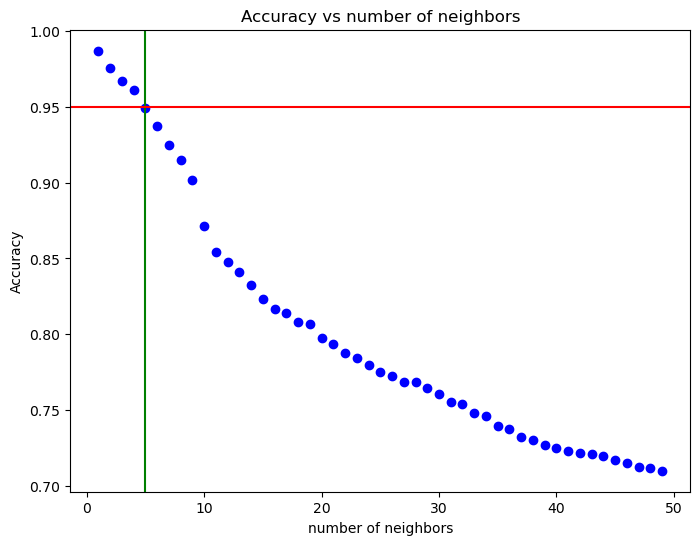

In [140]:
x = range(1,50)
y = np.array(acc)
plt.figure(figsize=(8, 6))
plt.scatter(x, y, color='blue', label='Punti')
plt.axvline(x=5, color="green", linestyle="-", linewidth=1.5)
plt.axhline(y=0.95, color="red", linestyle="-", linewidth=1.5)
plt.xlabel('number of neighbors')
plt.ylabel('Accuracy')
plt.title('Accuracy vs number of neighbors')

We can appreciate that we obtain a significant increase of the performance when we implement the KNN using the IDF vectors to 
represent each DNA sequence.
When we use the Levensthein distance, we notice that the accuracy is below 0.6 if we use more than 4 neighbours.
In this case the accuracy is above 0.7 even when we use 50 neighbours

In [141]:
cross_val_acc_ten = []
for i in range(1,11):
    knn_classifier = KNeighborsClassifier(n_neighbors=i, metric='precomputed')


    custom_scorer = make_scorer(accuracy_score)


    cross_val_scores = cross_val_score(knn_classifier,D_6, df_dist["16S copy number"], cv=10, scoring=custom_scorer)
    cross_val_acc_ten.append(cross_val_scores)


In [143]:
mean_acc_ten_6 = [np.mean(el) for el in cross_val_acc_ten]


### 9-kmer

In [144]:
sequences_comp_nine = df_dist["sequence"]

In [145]:
sequences_comp_nine = [str(seq) for seq in sequences_comp_nine]

In [146]:
l_nine = []
for i in range(len(sequences_comp_nine)):
    seq = sequences_comp_nine[i]
    length = len(seq)
    k_merized = kmer(seq,9)
    l_nine.append(k_merized)

In [147]:
df_dist["Kmer_9"] = l_nine

C:\Users\Simone\AppData\Local\Temp\ipykernel_20848\3299856103.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dist["Kmer_9"] = l_nine


In [148]:
tfidfvector = TfidfVectorizer()
X_nine = tfidfvector.fit_transform(df_dist['Kmer_9']).astype('float32')

In [149]:
D_nine = euclidean_distances(X_nine)

In [150]:
acc = []
for i in range(1,50):
    model = KNeighborsClassifier(n_neighbors=i, metric='precomputed')
    model.fit(D_nine,df_dist["16S copy number"])
    predictions = model.predict(D_nine)
    accuracy_knn = sum(predictions==df_dist["16S copy number"])/len(df_dist["16S copy number"])
    acc.append(accuracy_knn)
    misclass_knn = 1 - accuracy_knn

Text(0.5, 1.0, 'Accuracy vs number of neighbors')

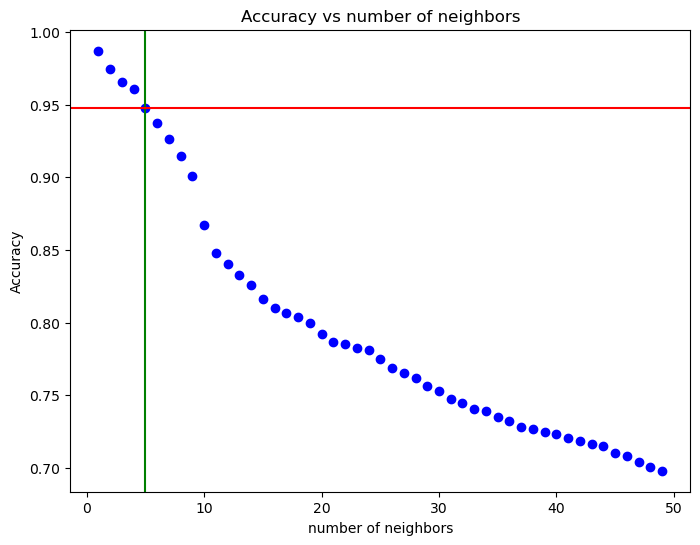

In [151]:
x = range(1,50)
y = np.array(acc)
plt.figure(figsize=(8, 6))  # Imposta le dimensioni della figura
plt.scatter(x, y, color='blue', label='Punti') 
plt.axvline(x=5, color="green", linestyle="-", linewidth=1.5)
plt.axhline(y=0.948, color="red", linestyle="-", linewidth=1.5)

plt.xlabel('number of neighbors')
plt.ylabel('Accuracy')
plt.title('Accuracy vs number of neighbors')

In [152]:
cross_val_acc_ten = []
for i in range(1,11):
    knn_classifier = KNeighborsClassifier(n_neighbors=i, metric='precomputed')


    custom_scorer = make_scorer(accuracy_score)

    cross_val_scores = cross_val_score(knn_classifier,D_nine, df_dist["16S copy number"], cv=10, scoring=custom_scorer)
    cross_val_acc_ten.append(cross_val_scores)


In [154]:
mean_acc_ten_9 = [np.mean(el) for el in cross_val_acc_ten]


### 12-kmer


In [155]:
sequences_comp_twelve = df_dist["sequence"]

In [156]:
sequences_comp_twelve = [str(seq) for seq in sequences_comp_twelve]
l_twelve = []
for i in range(len(sequences_comp_twelve)):
    seq = sequences_comp_twelve[i]
    k_merized = kmer(seq,12)
    l_twelve.append(k_merized)

In [157]:
df_dist["Kmer_12"] = l_twelve


C:\Users\Simone\AppData\Local\Temp\ipykernel_20848\363508637.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dist["Kmer_12"] = l_twelve


In [158]:
tfidfvector = TfidfVectorizer()
X_twelve = tfidfvector.fit_transform(df_dist['Kmer_12']).astype('float32')

In [159]:
D_twelve = euclidean_distances(X_twelve)

In [160]:
acc = []
for i in range(1,50):
    model = KNeighborsClassifier(n_neighbors=i, metric='precomputed')
    model.fit(D_twelve,df_dist["16S copy number"])
    predictions = model.predict(D_twelve)
    accuracy_knn = sum(predictions==df_dist["16S copy number"])/len(df_dist["16S copy number"])
    acc.append(accuracy_knn)
    misclass_knn = 1 - accuracy_knn

Text(0.5, 1.0, 'Accuracy vs number of neighbors')

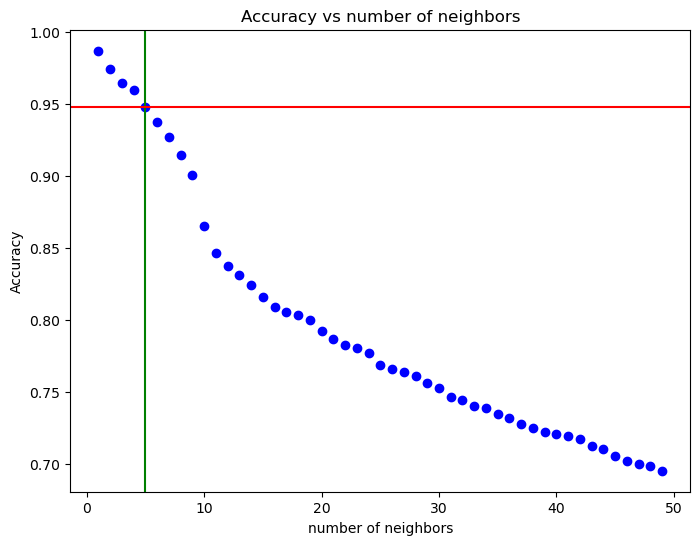

In [161]:
x = range(1,50)
y = np.array(acc)
plt.figure(figsize=(8, 6)) 
plt.scatter(x, y, color='blue', label='Punti') 
plt.axvline(x=5, color="green", linestyle="-", linewidth=1.5)
plt.axhline(y=0.948, color="red", linestyle="-", linewidth=1.5)
plt.xlabel('number of neighbors')
plt.ylabel('Accuracy')
plt.title('Accuracy vs number of neighbors')

In [162]:
cross_val_acc_ten = []
for i in range(1,11):
   
    knn_classifier = KNeighborsClassifier(n_neighbors=i, metric='precomputed')


    custom_scorer = make_scorer(accuracy_score)

    cross_val_scores = cross_val_score(knn_classifier,D_twelve, df_dist["16S copy number"], cv=10, scoring=custom_scorer)
    cross_val_acc_ten.append(cross_val_scores)

In [163]:
mean_acc_ten_12 = [np.mean(el) for el in cross_val_acc_ten]


### 15-kmer

In [164]:
sequences_comp_fifteen = df_dist["sequence"]

In [165]:
sequences_comp_fifteen = [str(seq) for seq in sequences_comp_fifteen]
l_fifteen = []
for i in range(len(sequences_comp_twelve)):
    seq = sequences_comp_fifteen[i]
    k_merized = kmer(seq,15)
    l_fifteen.append(k_merized)

In [166]:
df_dist["Kmer_15"] = l_fifteen

C:\Users\Simone\AppData\Local\Temp\ipykernel_20848\1996576150.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dist["Kmer_15"] = l_fifteen


In [167]:
tfidfvector = TfidfVectorizer()
X_fifteen = tfidfvector.fit_transform(df_dist['Kmer_15']).astype('float32')

In [168]:
D_fifteen = euclidean_distances(X_fifteen)

In [169]:
acc = []
for i in range(1,50):
    model = KNeighborsClassifier(n_neighbors=i, metric='precomputed')
    model.fit(D_fifteen,df_dist["16S copy number"])
    predictions = model.predict(D_fifteen)
    accuracy_knn = sum(predictions==df_dist["16S copy number"])/len(df_dist["16S copy number"])
    acc.append(accuracy_knn)
    misclass_knn = 1 - accuracy_knn

Text(0.5, 1.0, 'Accuracy vs number of neighbors')

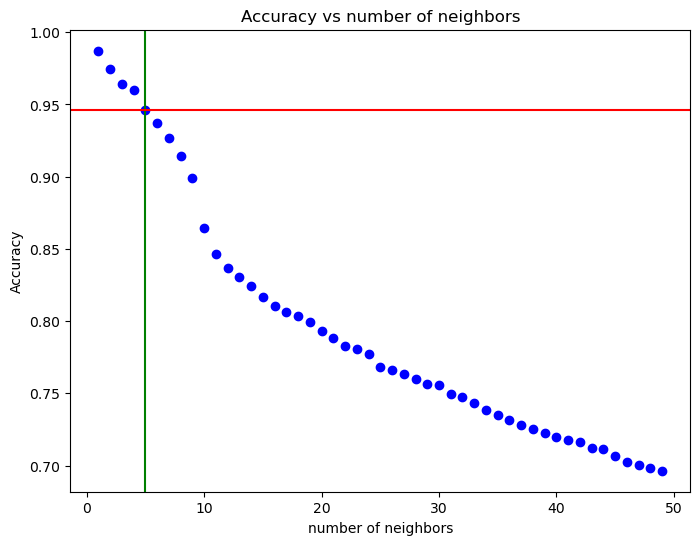

In [170]:
x = range(1,50)
y = np.array(acc)
plt.figure(figsize=(8, 6))
plt.scatter(x, y, color='blue', label='Punti') 
plt.xlabel('number of neighbors')
plt.axvline(x=5, color="green", linestyle="-", linewidth=1.5)
plt.axhline(y=0.946, color="red", linestyle="-", linewidth=1.5)
plt.ylabel('Accuracy')
plt.title('Accuracy vs number of neighbors')

In [171]:
cross_val_acc_ten = []
for i in range(1,11):
    knn_classifier = KNeighborsClassifier(n_neighbors=i, metric='precomputed')


    custom_scorer = make_scorer(accuracy_score)

    cross_val_scores = cross_val_score(knn_classifier,D_fifteen, df_dist["16S copy number"], cv=10, scoring=custom_scorer)
    cross_val_acc_ten.append(cross_val_scores)

In [183]:
mean_acc_ten_15 = [np.mean(el) for el in cross_val_acc_ten]


[0.7411566983816538, 0.7383184805384292, 0.7401849873463787, 0.7433231635504265, 0.7343598562611144, 0.7335379569564775, 0.729428460433293, 0.7267398310543418, 0.7221099564518957, 0.7176274376500769]


### 18-kmer

In [173]:
sequences_comp_18 = df_dist["sequence"]

In [174]:
sequences_comp_18 = [str(seq) for seq in sequences_comp_18]
l_18 = []
for i in range(len(sequences_comp_twelve)):
    seq = sequences_comp_fifteen[i]
    k_merized = kmer(seq,18)
    l_18.append(k_merized)

In [175]:
df_dist["Kmer_18"] = l_18

C:\Users\Simone\AppData\Local\Temp\ipykernel_20848\2780394417.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dist["Kmer_18"] = l_18


In [176]:
tfidfvector = TfidfVectorizer()
X_18 = tfidfvector.fit_transform(df_dist['Kmer_18']).astype('float32')

In [177]:
D_18 = euclidean_distances(X_18)

In [178]:
acc = []
for i in range(1,50):
    model = KNeighborsClassifier(n_neighbors=i, metric='precomputed')
    model.fit(D_18,df_dist["16S copy number"])
    predictions = model.predict(D_18)
    accuracy_knn = sum(predictions==df_dist["16S copy number"])/len(df_dist["16S copy number"])
    acc.append(accuracy_knn)
    misclass_knn = 1 - accuracy_knn

Text(0.5, 1.0, 'Accuracy vs number of neighbors')

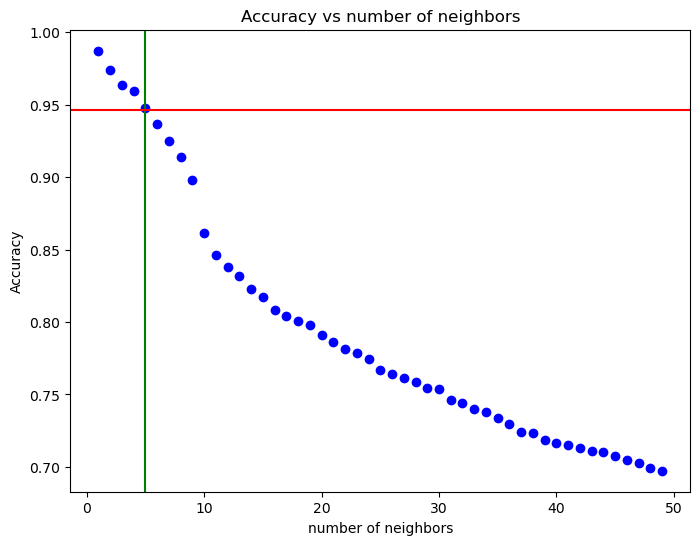

In [179]:
x = range(1,50)
y = np.array(acc)
plt.figure(figsize=(8, 6))
plt.scatter(x, y, color='blue', label='Punti')
plt.axvline(x=5, color="green", linestyle="-", linewidth=1.5)
plt.axhline(y=0.946, color="red", linestyle="-", linewidth=1.5)
plt.xlabel('number of neighbors')
plt.ylabel('Accuracy')
plt.title('Accuracy vs number of neighbors')

In [180]:
cross_val_acc_ten = []
for i in range(1,11):
    knn_classifier = KNeighborsClassifier(n_neighbors=i, metric='precomputed')

    custom_scorer = make_scorer(accuracy_score)
    cross_val_scores = cross_val_score(knn_classifier,D_18, df_dist["16S copy number"], cv=10, scoring=custom_scorer)
    cross_val_acc_ten.append(cross_val_scores)

In [181]:
mean_acc_ten_18 = [np.mean(el) for el in cross_val_acc_ten]


[0.7411566983816538, 0.7383184805384292, 0.7401849873463787, 0.7433231635504265, 0.7343598562611144, 0.7335379569564775, 0.729428460433293, 0.7267398310543418, 0.7221099564518957, 0.7176274376500769]


## Evaluation of KNN using kmers of different length

We use 10 fold cross validation to evaluate the performance of the classifier using kmers of different length

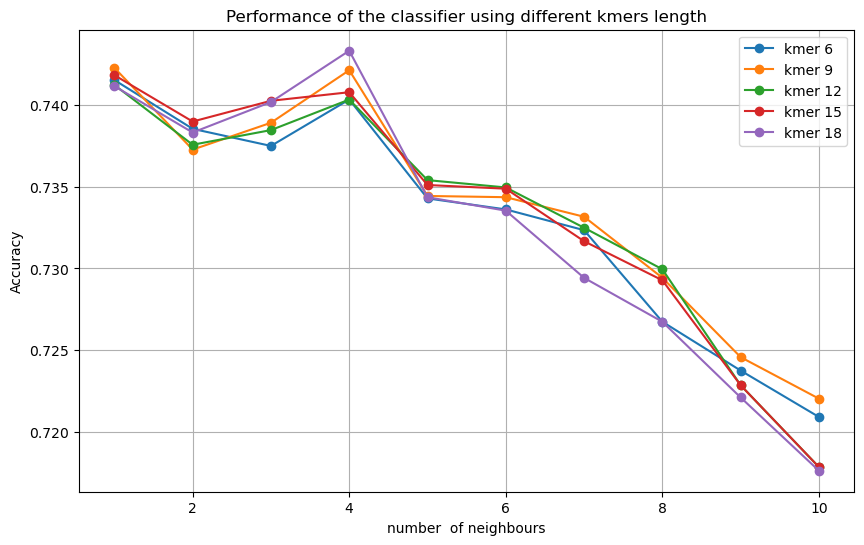

In [182]:
data = {'kmer 6':mean_acc_ten_6,
        'kmer 9': mean_acc_ten_9,
        'kmer 12':mean_acc_ten_12,
        'kmer 15':mean_acc_ten_15,
        'kmer 18':mean_acc_ten_18}

df = pd.DataFrame(data)


plt.figure(figsize=(10, 6))

for col in df.columns:
    plt.plot(df.index+1, df[col], label=col, marker='o')

plt.title('Performance of the classifier using different kmers length')
plt.xlabel('number  of neighbours')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()

As we can see from the plot, increasing the length of the kmers increase the accuracy of the classifier when we use a number of
neighbours coherent with our dataset.
A coherent number is between 1 and 5 because we have build the dataset in a way that there are no more than 5 sequences per specie.
We can see how increasing the kmer length results in increasing the resolution power of the classifier of correctly predict
16S copy number

## Dimensionality Reduction

As the length of the kmer increases, it exponentialy increases the dimension of the IDF vector that represents the sequence

For example,if k=9, we have a vector of length 262144 that describes the sequence. 
In addition to this, as we increase the kmer length, the vector that describes the sequence becomes more sparse and we know 
that it becomes more complicated to compute euclidean distance in high dimensionaly settings
So, for these two reasons it could be useful to perform some dimensionality reduction on our data and then apply the KNN classifier
on the reduced space.

### 6-kmer

In [185]:
max_components = 1500

svd = TruncatedSVD(n_components=max_components)
svd.fit(X_6)

TruncatedSVD(n_components=1500)

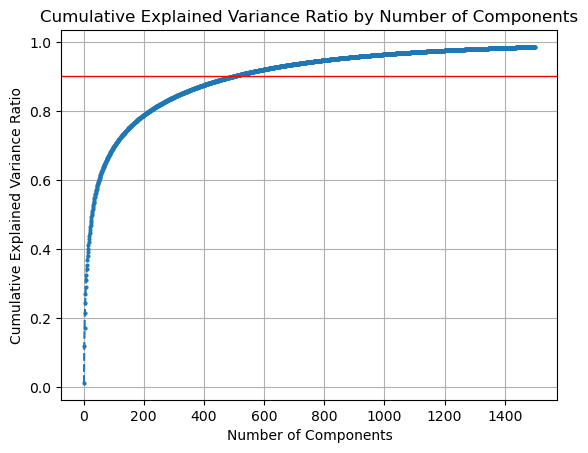

In [186]:
plt.plot(np.arange(1, max_components + 1), np.cumsum(svd.explained_variance_ratio_), marker="o", linestyle="--", markersize=2)
plt.axhline(y=0.9, color="red", linestyle="-", linewidth=1)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance Ratio")
plt.title("Cumulative Explained Variance Ratio by Number of Components")
plt.grid(True)
plt.show()


I want to see in a quick way if the number of components choosen is able to explain 90% of the variance in my dataset

In [187]:
X_transformed = svd.transform(X_6)

In [188]:
D_6_red = euclidean_distances(X_transformed)

In [189]:
acc = []
for i in range(1,50):
    model = KNeighborsClassifier(n_neighbors=i, metric='precomputed')
    model.fit(D_6_red,df_dist["16S copy number"])
    predictions = model.predict(D_6_red)
    accuracy_knn = sum(predictions==df_dist["16S copy number"])/len(df_dist["16S copy number"])
    acc.append(accuracy_knn)
    misclass_knn = 1 - accuracy_knn

Text(0.5, 1.0, 'Accuracy vs number of neighbors')

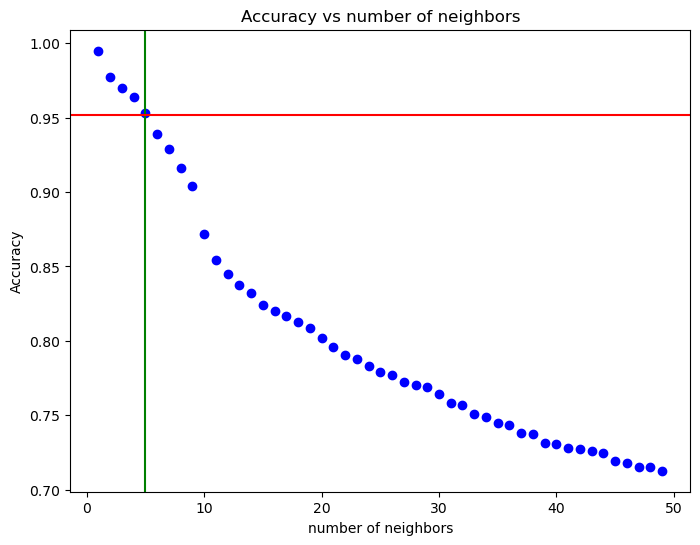

In [190]:
x = range(1,50)
y = np.array(acc)
plt.figure(figsize=(8, 6))
plt.scatter(x, y, color='blue', label='Punti') 
plt.axvline(x=5, color="green", linestyle="-", linewidth=1.5)
plt.axhline(y=0.952, color="red", linestyle="-", linewidth=1.5)
plt.xlabel('number of neighbors')
plt.ylabel('Accuracy')
plt.title('Accuracy vs number of neighbors')

In [191]:
cross_val_acc_ten = []
for i in range(1,11):
    knn_classifier = KNeighborsClassifier(n_neighbors=i, metric='precomputed')

    custom_scorer = make_scorer(accuracy_score)

    cross_val_scores = cross_val_score(knn_classifier,D_6_red, df_dist["16S copy number"], cv=10, scoring=custom_scorer)
    cross_val_acc_ten.append(cross_val_scores)

In [192]:
mean_acc_ten_6_red = [np.mean(el) for el in cross_val_acc_ten]
print(mean_acc_ten_6_red)

[0.7415306137257464, 0.7379468536745737, 0.7399631722131613, 0.7406377157171706, 0.7350346230314884, 0.7328677113299865, 0.7334644465059373, 0.7293575175459455, 0.7254726828021268, 0.7223348973142172]


In [193]:
perc = (1500/4**6)*100
print(perc)

36.62109375


If we use the first 1500 components, it corresponds to the 36% of the total components

### 9-kmer

In [194]:
max_components = 1500

svd = TruncatedSVD(n_components=max_components)
svd.fit(X_nine)

TruncatedSVD(n_components=1500)

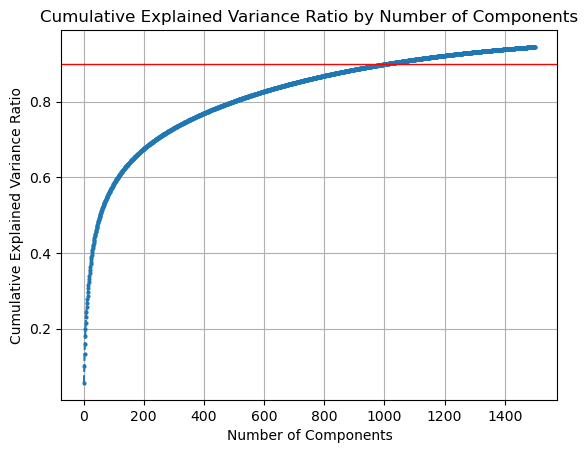

In [195]:
plt.plot(np.arange(1, max_components + 1), np.cumsum(svd.explained_variance_ratio_), marker="o", linestyle="--", markersize=2)
plt.axhline(y=0.9, color="red", linestyle="-", linewidth=1)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance Ratio")
plt.title("Cumulative Explained Variance Ratio by Number of Components")
plt.grid(True)
plt.show()

In [196]:
X_transformed = svd.transform(X_nine)

In [197]:
D_9_red = euclidean_distances(X_transformed)

In [198]:
acc = []
for i in range(1,50):
    model = KNeighborsClassifier(n_neighbors=i, metric='precomputed')
    model.fit(D_9_red,df_dist["16S copy number"])
    predictions = model.predict(D_9_red)
    accuracy_knn = sum(predictions==df_dist["16S copy number"])/len(df_dist["16S copy number"])
    acc.append(accuracy_knn)
    misclass_knn = 1 - accuracy_knn

Text(0.5, 1.0, 'Accuracy vs number of neighbors')

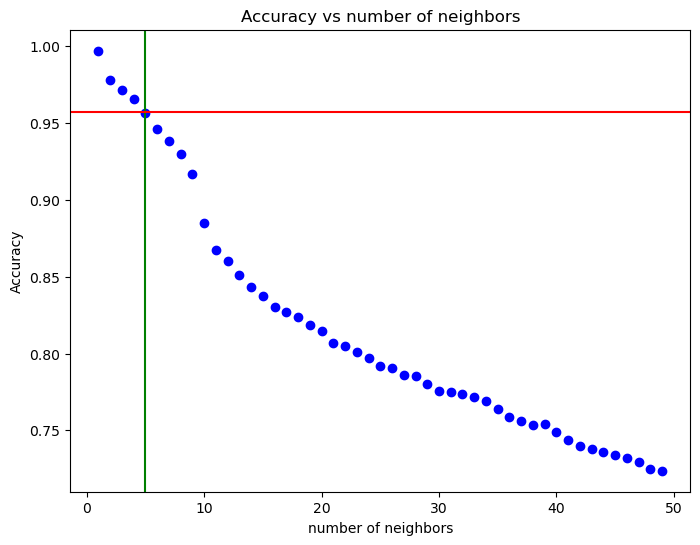

In [199]:
x = range(1,50)
y = np.array(acc)
plt.figure(figsize=(8, 6))
plt.scatter(x, y, color='blue', label='Punti') 
plt.axvline(x=5, color="green", linestyle="-", linewidth=1.5)
plt.axhline(y=0.957, color="red", linestyle="-", linewidth=1.5)
plt.xlabel('number of neighbors')
plt.ylabel('Accuracy')
plt.title('Accuracy vs number of neighbors')

In [200]:
cross_val_acc_ten = []
for i in range(1,11):
    knn_classifier = KNeighborsClassifier(n_neighbors=i, metric='precomputed')

    custom_scorer = make_scorer(accuracy_score)

    cross_val_scores = cross_val_score(knn_classifier,D_9_red, df_dist["16S copy number"], cv=10, scoring=custom_scorer)
    cross_val_acc_ten.append(cross_val_scores)

In [201]:
mean_acc_ten_9_red = [np.mean(el) for el in cross_val_acc_ten]


In [202]:
perc = (1500/4**9)*100
print(perc)

0.57220458984375


If we use the first 1500 components, it corresponds to the 0.57 % of the total components. 
We can appreciate how with kmer of length 6, 1500 corespond to the 36% of total components in the dataset.
We can see how we have a small,almost negligeble reduction in accuracy but a much greater reduction in dimensionality

we try doubling the number of components

In [203]:
max_components = 3000

svd = TruncatedSVD(n_components=max_components)
svd.fit(X_nine)

TruncatedSVD(n_components=3000)

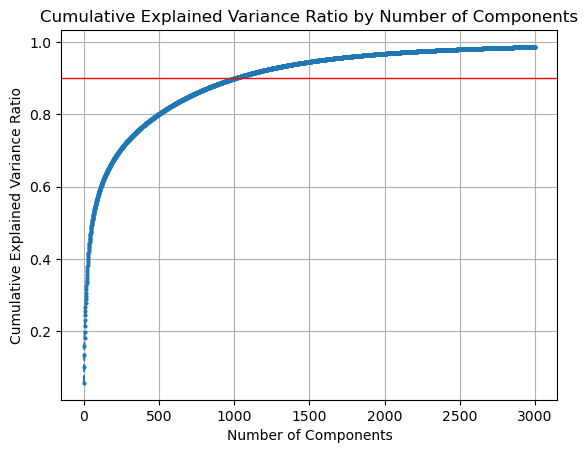

In [204]:
plt.plot(np.arange(1, max_components + 1), np.cumsum(svd.explained_variance_ratio_), marker="o", linestyle="--", markersize=2)
plt.axhline(y=0.9, color="red", linestyle="-", linewidth=1)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance Ratio")
plt.title("Cumulative Explained Variance Ratio by Number of Components")
plt.grid(True)
plt.show()

In [205]:
X_transformed = svd.transform(X_nine)

In [206]:
D_9_red_3k = euclidean_distances(X_transformed)

In [207]:
acc = []
for i in range(1,50):
    model = KNeighborsClassifier(n_neighbors=i, metric='precomputed')
    model.fit(D_9_red_3k,df_dist["16S copy number"])
    predictions = model.predict(D_9_red_3k)
    accuracy_knn = sum(predictions==df_dist["16S copy number"])/len(df_dist["16S copy number"])
    acc.append(accuracy_knn)
    misclass_knn = 1 - accuracy_knn

Text(0.5, 1.0, 'Accuracy vs number of neighbors')

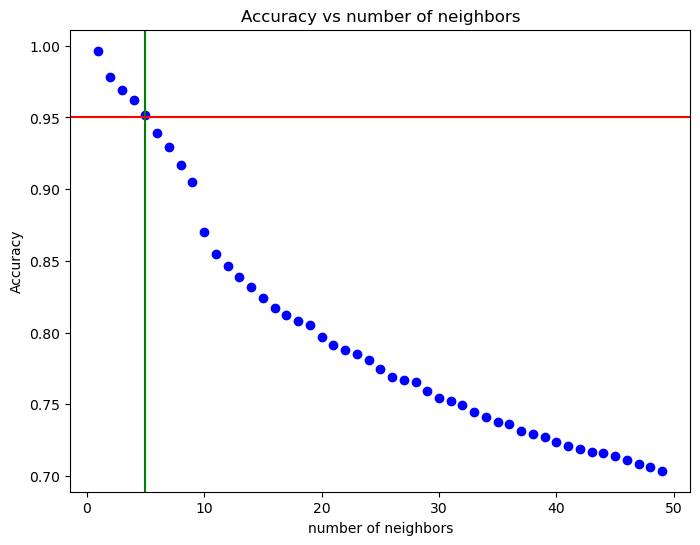

In [208]:
x = range(1,50)
y = np.array(acc)
plt.figure(figsize=(8, 6))
plt.scatter(x, y, color='blue', label='Punti') 
plt.axvline(x=5, color="green", linestyle="-", linewidth=1.5)
plt.axhline(y=0.95, color="red", linestyle="-", linewidth=1.5)
plt.xlabel('number of neighbors')
plt.ylabel('Accuracy')
plt.title('Accuracy vs number of neighbors')

In [209]:
cross_val_acc_ten = []
for i in range(1,11):
    knn_classifier = KNeighborsClassifier(n_neighbors=i, metric='precomputed')

    custom_scorer = make_scorer(accuracy_score)

    cross_val_scores = cross_val_score(knn_classifier,D_9_red_3k, df_dist["16S copy number"], cv=10, scoring=custom_scorer)
    cross_val_acc_ten.append(cross_val_scores)

In [210]:
mean_acc_ten_9_red_3k = [np.mean(el) for el in cross_val_acc_ten]


### Evaluation of classifier using 9-kmer with different number of PC

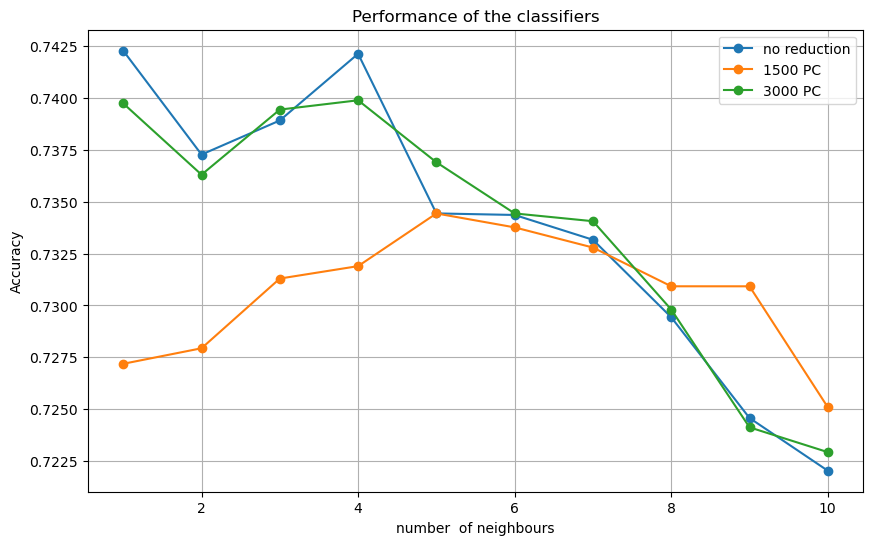

In [211]:
data = {'no reduction':mean_acc_ten_9,
        '1500 PC': mean_acc_ten_9_red,
        '3000 PC':mean_acc_ten_9_red_3k,
        }

df = pd.DataFrame(data)


plt.figure(figsize=(10, 6))

for col in df.columns:
    plt.plot(df.index+1, df[col], label=col, marker='o')

plt.title('Performance of the classifiers')
plt.xlabel('number  of neighbours')
plt.ylabel('Accuracy')
plt.legend() 
plt.grid()
plt.show()

We can see that we have the highest accuracy around a coherent number of neighbours if we don't apply dimensionality reduction.
This is expected since every dimensionality reduction technique is associated with a loss of information.
Interestingly, the accuracy of the classifier with less dimensions is higher wrt to the others classifier when we increase the 
number of neighbours

Unluckily, for memory problems, it was not possible to extent this kind of analysis and increase the number of PCs for
kmers of length greater than 9

### 12-kmer

In [212]:
max_components = 1500

svd = TruncatedSVD(n_components=max_components)
svd.fit(X_twelve)


TruncatedSVD(n_components=1500)

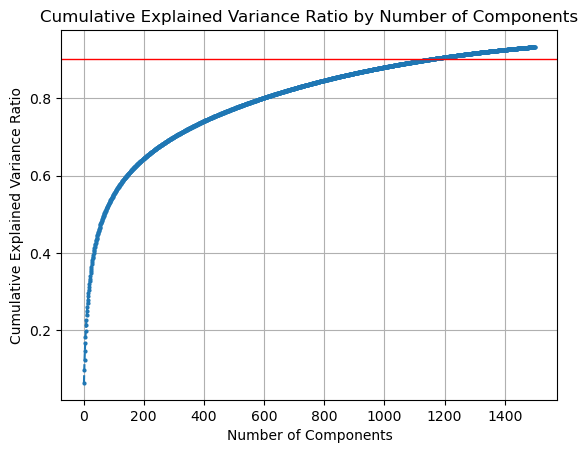

In [213]:


plt.plot(np.arange(1, max_components + 1), np.cumsum(svd.explained_variance_ratio_), marker="o", linestyle="--", markersize=2)
plt.axhline(y=0.9, color="red", linestyle="-", linewidth=1)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance Ratio")
plt.title("Cumulative Explained Variance Ratio by Number of Components")
plt.grid(True)
plt.show()


In [214]:
X_transformed = svd.transform(X_twelve)

In [215]:
D_12_red = euclidean_distances(X_transformed)

In [216]:
acc = []
for i in range(1,50):
    model = KNeighborsClassifier(n_neighbors=i, metric='precomputed')
    model.fit(D_12_red,df_dist["16S copy number"])
    predictions = model.predict(D_12_red)
    accuracy_knn = sum(predictions==df_dist["16S copy number"])/len(df_dist["16S copy number"])
    acc.append(accuracy_knn)
    misclass_knn = 1 - accuracy_knn

Text(0.5, 1.0, 'Accuracy vs number of neighbors')

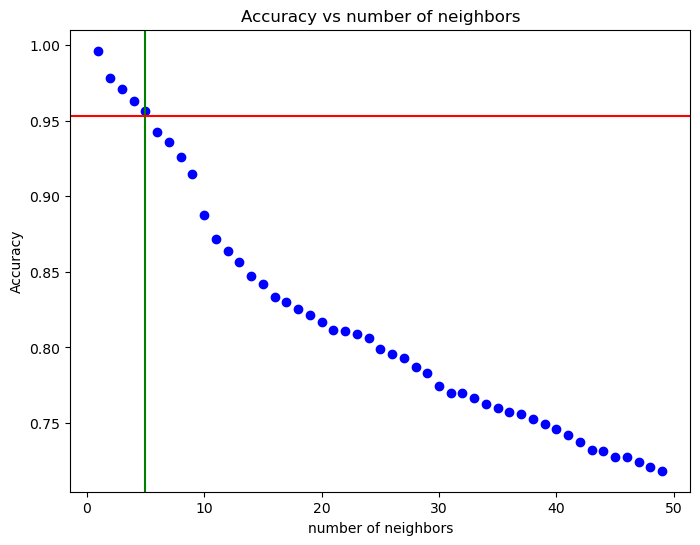

In [217]:
x = range(1,50)
y = np.array(acc)
plt.figure(figsize=(8, 6)) 
plt.scatter(x, y, color='blue', label='Punti') 
plt.axvline(x=5, color="green", linestyle="-", linewidth=1.5)
plt.axhline(y=0.953, color="red", linestyle="-", linewidth=1.5)
plt.xlabel('number of neighbors')
plt.ylabel('Accuracy')
plt.title('Accuracy vs number of neighbors')

In [218]:
cross_val_acc_ten = []
for i in range(1,11):
    knn_classifier = KNeighborsClassifier(n_neighbors=i, metric='precomputed')

    custom_scorer = make_scorer(accuracy_score)

    cross_val_scores = cross_val_score(knn_classifier,D_12_red, df_dist["16S copy number"], cv=10, scoring=custom_scorer)
    cross_val_acc_ten.append(cross_val_scores)

In [219]:
mean_acc_ten_12_red = [np.mean(el) for el in cross_val_acc_ten]

In [220]:
perc = (1500/4**12)*100
print(perc)

0.008940696716308594


If we use the first 1500 components, it corresponds to the 0.009 % of the total components.
We can appreciate how with kmer of length 6, 1500 corespond to the 36% of total components in the dataset.
We can see how we have a small reduction in accuracy but a much greater reduction in dimensionality.

### 15-kmer

In [221]:
max_components = 1500


svd = TruncatedSVD(n_components=max_components)
svd.fit(X_fifteen)




TruncatedSVD(n_components=1500)

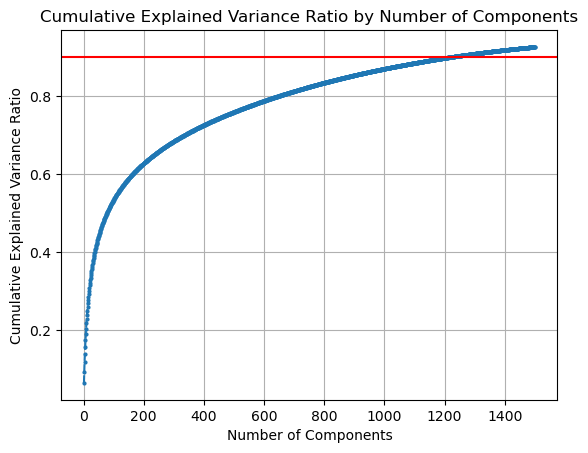

In [222]:
plt.plot(np.arange(1, max_components + 1), np.cumsum(svd.explained_variance_ratio_), marker="o", linestyle="--", markersize=2)
plt.xlabel("Number of Components")
plt.axhline(y=0.9, color="red", linestyle="-", linewidth=1.5)
plt.ylabel("Cumulative Explained Variance Ratio")
plt.title("Cumulative Explained Variance Ratio by Number of Components")
plt.grid(True)
plt.show()

In [223]:
X_transformed_15 = svd.transform(X_fifteen)

In [224]:
D_15_red = euclidean_distances(X_transformed_15)

In [241]:
acc = []
for i in range(1,50):
    model = KNeighborsClassifier(n_neighbors=i, metric='precomputed')
    model.fit(D_15_red,df_dist["16S copy number"])
    predictions = model.predict(D_15_red)
    accuracy_knn = sum(predictions==df_dist["16S copy number"])/len(df_dist["16S copy number"])
    acc.append(accuracy_knn)
    misclass_knn = 1 - accuracy_knn

Text(0.5, 1.0, 'Accuracy vs number of neighbors')

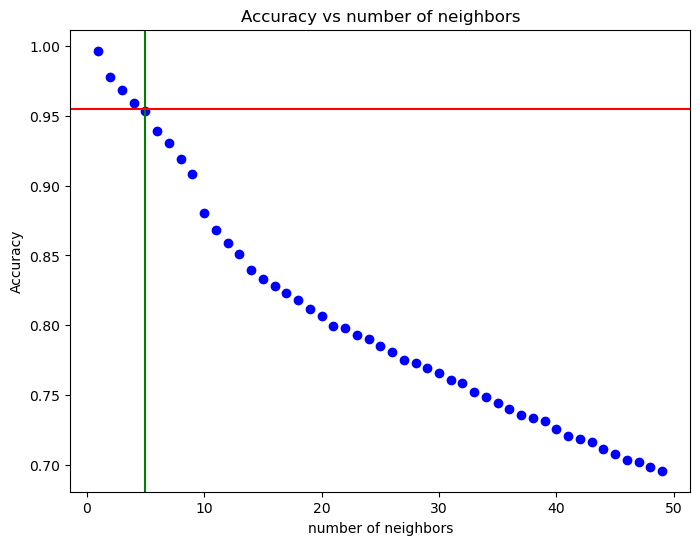

In [242]:
x = range(1,50)
y = np.array(acc)
plt.figure(figsize=(8, 6))  # Imposta le dimensioni della figura
plt.scatter(x, y, color='blue', label='Punti')
plt.axvline(x=5, color="green", linestyle="-", linewidth=1.5)
plt.axhline(y=0.955, color="red", linestyle="-", linewidth=1.5)
plt.xlabel('number of neighbors')
plt.ylabel('Accuracy')
plt.title('Accuracy vs number of neighbors')

In [227]:
cross_val_acc_ten = []
for i in range(1,11):
    knn_classifier = KNeighborsClassifier(n_neighbors=i, metric='precomputed')

    custom_scorer = make_scorer(accuracy_score)


    cross_val_scores = cross_val_score(knn_classifier,D_15_red, df_dist["16S copy number"], cv=10, scoring=custom_scorer)
    cross_val_acc_ten.append(cross_val_scores)

In [228]:
mean_acc_ten_15_red = [np.mean(el) for el in cross_val_acc_ten]

In [229]:
perc = (1500/4**15)*100
print(perc)

0.00013969838619232178


If we use the first 1500 components, it corresponds to the 0.0001 % of the total components. We can appreciate how with kmer of length 6, 1500 corespond to the 36% of total components in the dataset. 
We can see how we have a small reduction in accuracy but a huge reduction in dimensionality.

### 18-kmer

In [230]:
max_components = 1500

svd = TruncatedSVD(n_components=max_components)
svd.fit(X_18)

TruncatedSVD(n_components=1500)

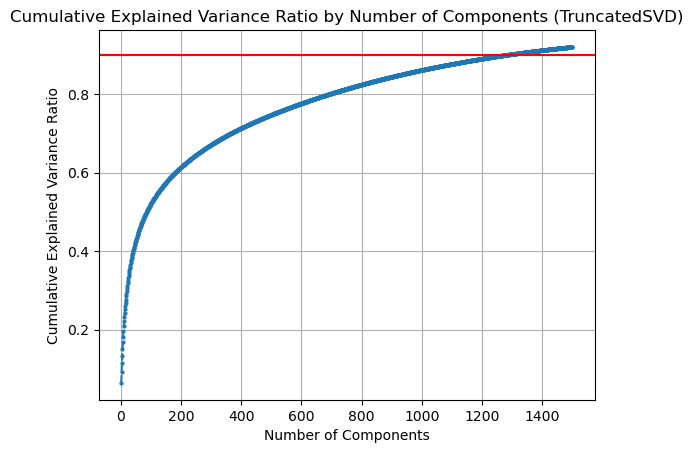

In [231]:
plt.plot(np.arange(1, max_components + 1), np.cumsum(svd.explained_variance_ratio_), marker="o", linestyle="--", markersize=2)
plt.xlabel("Number of Components")
plt.axhline(y=0.9, color="red", linestyle="-", linewidth=1.5)
plt.ylabel("Cumulative Explained Variance Ratio")
plt.title("Cumulative Explained Variance Ratio by Number of Components (TruncatedSVD)")
plt.grid(True)
plt.show()

In [232]:
X_transformed_18 = svd.transform(X_18)

In [233]:
D_18_red = euclidean_distances(X_transformed_18)

In [234]:
acc = []
for i in range(1,50):
    model = KNeighborsClassifier(n_neighbors=i, metric='precomputed')
    model.fit(D_18_red,df_dist["16S copy number"])
    predictions = model.predict(D_18_red)
    accuracy_knn = sum(predictions==df_dist["16S copy number"])/len(df_dist["16S copy number"])
    acc.append(accuracy_knn)
    misclass_knn = 1 - accuracy_knn

Text(0.5, 1.0, 'Accuracy vs number of neighbors')

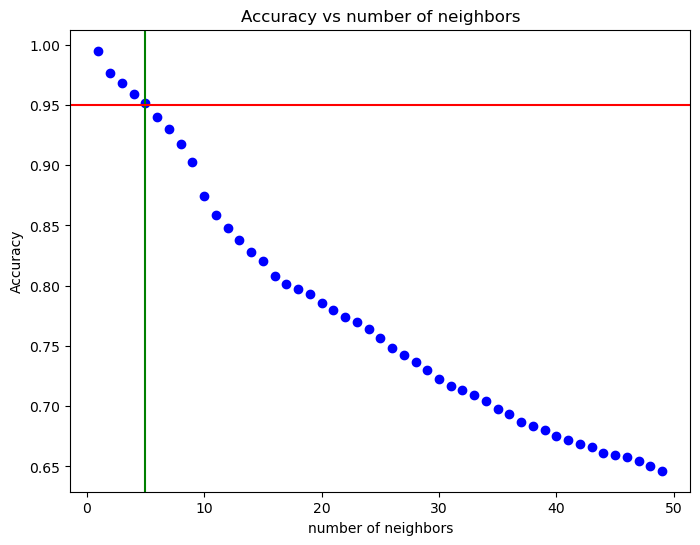

In [235]:
x = range(1,50)
y = np.array(acc)
plt.figure(figsize=(8, 6)) 
plt.scatter(x, y, color='blue', label='Punti')
plt.axvline(x=5, color="green", linestyle="-", linewidth=1.5)
plt.axhline(y=0.95, color="red", linestyle="-", linewidth=1.5)
plt.xlabel('number of neighbors')
plt.ylabel('Accuracy')
plt.title('Accuracy vs number of neighbors')

In [236]:
cross_val_acc_ten = []
for i in range(1,11):
    knn_classifier = KNeighborsClassifier(n_neighbors=i, metric='precomputed')


    custom_scorer = make_scorer(accuracy_score)


    cross_val_scores = cross_val_score(knn_classifier,D_18_red, df_dist["16S copy number"], cv=10, scoring=custom_scorer)
    cross_val_acc_ten.append(cross_val_scores)

In [237]:
mean_acc_ten_18_red = [np.mean(el) for el in cross_val_acc_ten]

In [238]:
perc = (1500/4**18)*100
print(perc)

2.1827872842550278e-06


If we use the first 1500 components, it corresponds to the 2.1827872842550278e-06 % of the total components. We can appreciate how with kmer of length 6, 1500 corespond to the 36% of total components in the dataset.
We can see how we have a small reduction in accuracy but a huge reduction in dimensionality.

### Evaluation of the classifier in the reduced space

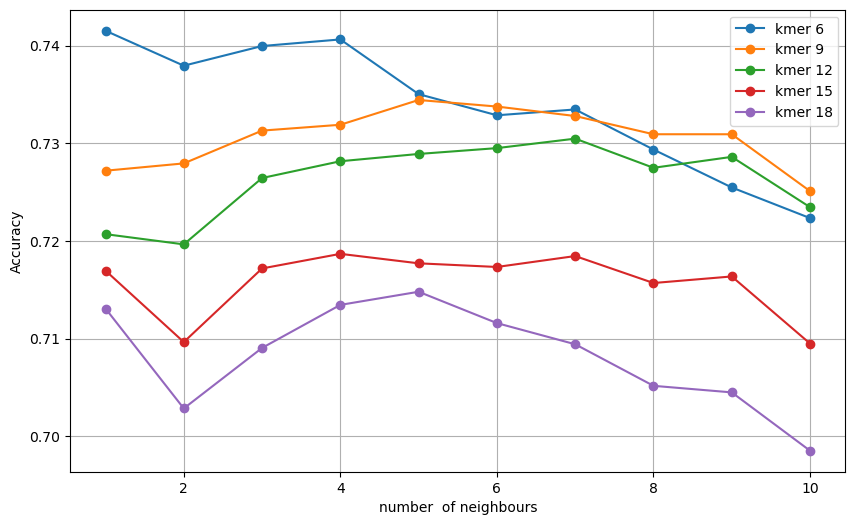

In [239]:
data = {'kmer 6':mean_acc_ten_6_red,
        'kmer 9': mean_acc_ten_9_red,
        'kmer 12':mean_acc_ten_12_red,
        'kmer 15':mean_acc_ten_15_red,
        'kmer 18':mean_acc_ten_18_red}

df = pd.DataFrame(data)


plt.figure(figsize=(10, 6))

for col in df.columns:
    plt.plot(df.index+1, df[col], label=col, marker='o')


plt.xlabel('number  of neighbours')
plt.ylabel('Accuracy')
plt.legend() 
plt.grid()
plt.show()

We can see that after data reduction the classifier with the highest accuracy is the one using kmer of length 6.
This is expected because for every kmer we decide to use the first 1500 principal components.
For the kmer of length 6, this correspond to the 36% of the original dimensions, while for kmers of greater length it correspond
to % of the original dataseet close to 0.
So if we take the first 1500 principal components for kmers of length greater than 6, they represent just a small fraction of the 
original dataset, while for kmer of length 6 it correspond to more than 1/3 of the original dataset.
Hence the higher accuracy of the classifier with 6-kmers

### Evaluation of all classifiers

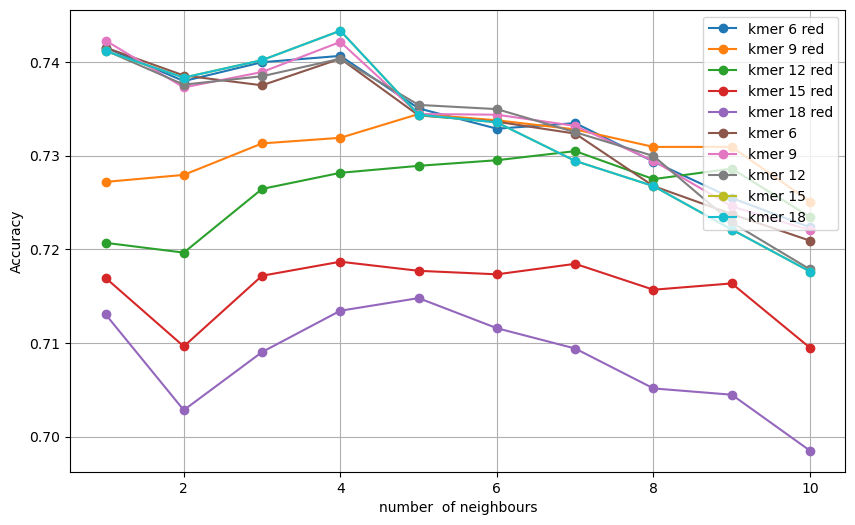

In [240]:
data = {'kmer 6 red':mean_acc_ten_6_red,
        'kmer 9 red': mean_acc_ten_9_red,
        'kmer 12 red':mean_acc_ten_12_red,
        'kmer 15 red':mean_acc_ten_15_red,
        'kmer 18 red':mean_acc_ten_18_red,
        'kmer 6':mean_acc_ten_6,
        'kmer 9': mean_acc_ten_9,
        'kmer 12':mean_acc_ten_12,
        'kmer 15':mean_acc_ten_15,
        'kmer 18':mean_acc_ten_18
       }

df = pd.DataFrame(data)


plt.figure(figsize=(10, 6))

for col in df.columns:
    plt.plot(df.index+1, df[col], label=col, marker='o')


plt.xlabel('number  of neighbours')
plt.ylabel('Accuracy')
plt.legend(loc='upper right') 
plt.grid()
plt.show()

From this plot we can see the 2 phenomena described above.

As we increase the length of the kmer, the accuracy of the classifier increases when using a coherent number of neighbours.
When we perform dimensionality reduction, since we use the same number of PCs for every kmer, kmer of smaller length result in 
a smaller dimensionality reduction compared to the longer ones, and consequentionally a reduced loss of information.

### Hierarchical clustering in the reduced space

Since we have seen an important increase of performances of the classifier switching from the string representation of the 16S sequence to the IDF
representation, we repeat the clustering analysis on the IDF representation of the 16S sequences.
We expect to see an increase in the accuracy of the clustering algorithm, now that data are not raw sequences but vectorial representations
of those sequences, and distance based clustering algorithms tend to perform better when the data live in an Euclidean space

###  Simple Hierachical clustering using 6-kmer

In [243]:
hierarchical_cluster = AgglomerativeClustering(n_clusters=3465,affinity='precomputed', 
    linkage='average')

In [244]:
clusters = hierarchical_cluster.fit_predict(D_6)

C:\Simone\anaconda3\lib\site-packages\sklearn\cluster\_agglomerative.py:983: FutureWarning: Attribute `affinity` was deprecated in version 1.2 and will be removed in 1.4. Use `metric` instead
  warnings.warn(


In [245]:
df_dist['Cluster red'] = clusters

C:\Users\Simone\AppData\Local\Temp\ipykernel_20848\148775344.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dist['Cluster red'] = clusters


In [246]:
one_seq_df = df_dist[df_dist["ID"].isin(one_seq_ids)].reset_index(drop=True)

In [247]:
clus_idxs = one_seq_df["Cluster red"].tolist()

In [248]:
uniq_clus = df_dist[df_dist["Cluster red"].isin(clus_idxs)]

In [249]:
one_seq_clus = uniq_clus.groupby("Cluster red").filter(lambda x: len(x) == 1)
print(f'there are {one_seq_clus.shape[0]} clusters correctly made of only one member out of 306 true one member clusters')

there are 152 clusters correctly made of only one member out of 306 true one member clusters


We observe an enourmous increase of the ability of correctly identifying true one member clusters. With the classical implementation
we were able to identify only 10% of true one member cluster, while with the same algorithm implemented on the trasformed data we are
able to identify close to 50% of them.

### Specie composition of each cluster

In [250]:
species_per_cluster = df_dist.groupby('Cluster red')['Specie'].nunique()

In [251]:
species_per_clust_entropy_kmer = df_dist.groupby('Cluster red')['Specie']

In [252]:
entropy_list = []
one_seq_clus = 0
zero_entropy_more_than_one = 0
for el in species_per_clust_entropy_kmer:
    count = el[1].value_counts(normalize=True)
    if len(el[1]) == 1:
        E = 0
        one_seq_clus = one_seq_clus+1
        entropy_list.append(E)
    else:
        E = -sum(np.log2(count)*count)
        if E == -0.0:
            E = 0
            zero_entropy_more_than_one= zero_entropy_more_than_one+1
            entropy_list.append(E)
        else:
            entropy_list.append(E)

In [253]:
print(f'there are {zero_entropy_more_than_one} clusters that have 0 entropy but they are made of more than one sequence,while there are {one_seq_clus} that have 0 entropy and only one sequence')

there are 1350 clusters that have 0 entropy but they are made of more than one sequence,while there are 1628 that have 0 entropy and only one sequence


We observe again an increase of the performance,with respect to the Hierachical clustering implemented on raw sequences.
In fact we find around 650 clusters more made of multiple sequences that have 0 entropy (1350 vs 609)

Text(0.5, 1.0, 'Entropy of each cluster')

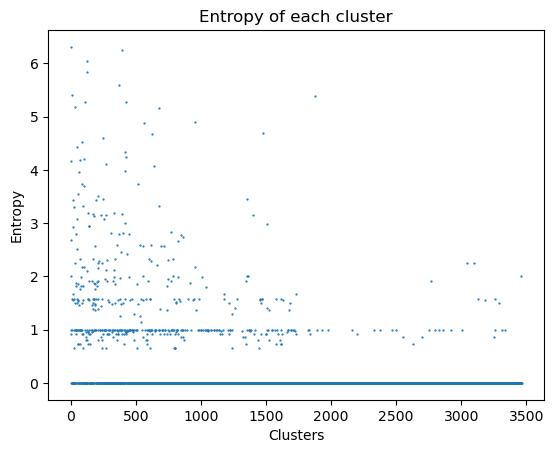

In [254]:
plt.plot(range(len(entropy_list)), entropy_list, 'o',markersize=0.6)

plt.xlabel('Clusters')
plt.ylabel('Entropy')
plt.title('Entropy of each cluster')

We don't observe extreme values of Entropy compared to Hierarchical clustering implemented on raw sequences data

### Genus composition of each cluster

In [255]:
genus_per_clust_entropy = df_dist.groupby('Cluster red')['Genus']

In [256]:
entropy_list_genus = []
one_seq_clus_genus = 0
zero_entropy_more_than_one_genus = 0
for el in genus_per_clust_entropy:
    count = el[1].value_counts(normalize=True)
    if len(el[1]) == 1:
        E = 0
        one_seq_clus_genus = one_seq_clus_genus+1
        entropy_list_genus.append(E)
    else:
        E = -sum(np.log2(count)*count)
        if E == -0.0:
            E = 0
            zero_entropy_more_than_one_genus= zero_entropy_more_than_one_genus+1
            entropy_list_genus.append(E)
        else:
            entropy_list_genus.append(E)
        

Text(0.5, 1.0, 'Entropy of each cluster based on Genus composition')

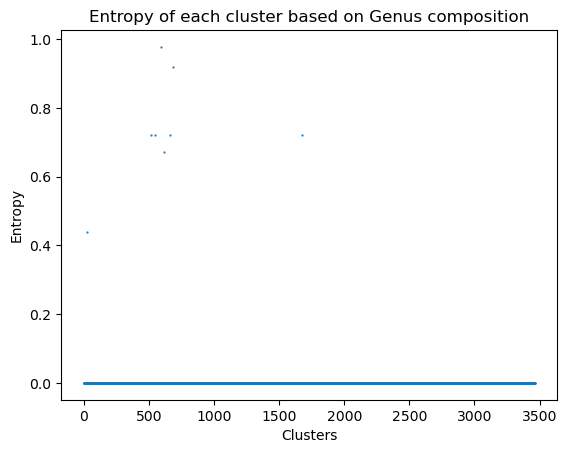

In [257]:
plt.plot(range(len(entropy_list_genus)), entropy_list_genus, 'o',markersize=0.6)

plt.xlabel('Clusters')
plt.ylabel('Entropy')
plt.title('Entropy of each cluster based on Genus composition')

We can notice a tremendous increase of the performance of the clustering algorithm. We can see that almost every cluster has 0 entropy,
and just few outliers have entropy values of their cluster greater than 0 but lower than 1, while the clusters obtained on 
raw sequences data had much many clusters with entropy greater than 0, also with bigger values of entropy.
This means that the clustering algorithm is able to capture the genus composition of our dataset

In [258]:
print(f'there are {zero_entropy_more_than_one_genus} clusters that have 0 entropy but they are made of more than one sequence')

there are 1829 clusters that have 0 entropy but they are made of more than one sequence


We observe a 500 increase in the number of clusters with 0 entropy but more than one sequence based on genus composition.
This means that our clustering algorithm is able to capture the specie and genus division in the dataset,providing good
agreement with the phylogenetic trees.

### Family composition of each cluster

In [259]:
family_per_clust_entropy = df_dist.groupby('Cluster red')['Family']

In [260]:
entropy_list_fam = []
one_seq_clus_fam = 0
zero_entropy_more_than_one_fam = 0
for el in family_per_clust_entropy:
    count = el[1].value_counts(normalize=True)
    if len(el[1]) == 1:
        E = 0
        one_seq_clus_fam = one_seq_clus_fam+1
        entropy_list_fam.append(E)
    else:
        E = -sum(np.log2(count)*count)
        if E == -0.0:
            E = 0
            zero_entropy_more_than_one_fam= zero_entropy_more_than_one_fam+1
            entropy_list_fam.append(E)
        else:
            entropy_list_fam.append(E)
        

Text(0.5, 1.0, 'Entropy of each cluster based on family composition')

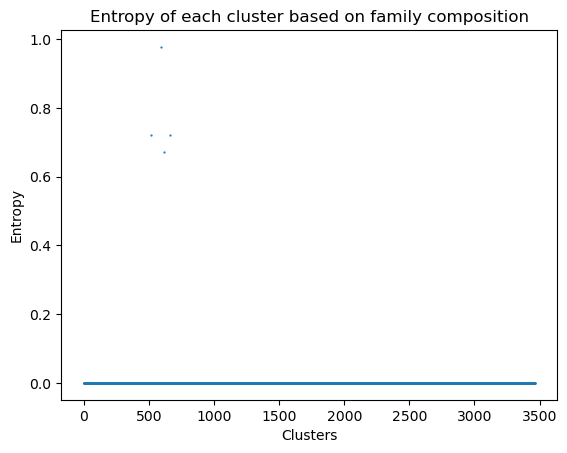

In [261]:
plt.plot(range(len(entropy_list_fam)), entropy_list_fam, 'o',markersize=0.6)

plt.xlabel('Clusters')
plt.ylabel('Entropy')
plt.title('Entropy of each cluster based on family composition')

In [262]:
print(f'there are {zero_entropy_more_than_one_fam} clusters that have 0 entropy but they are made of more than one sequence')

there are 1833 clusters that have 0 entropy but they are made of more than one sequence


Again we observe a tremendous increase of the ability of the clustering algorithm to correctly identify the family composition.
of our dataset.
This performance was not observed in case of the classical implementation and Genie implementation of hierarchical clustering
on raw sequences

### Numerosity Analysis of the clusters

In [263]:
members_per_clust = df_dist.groupby('Cluster red').size()

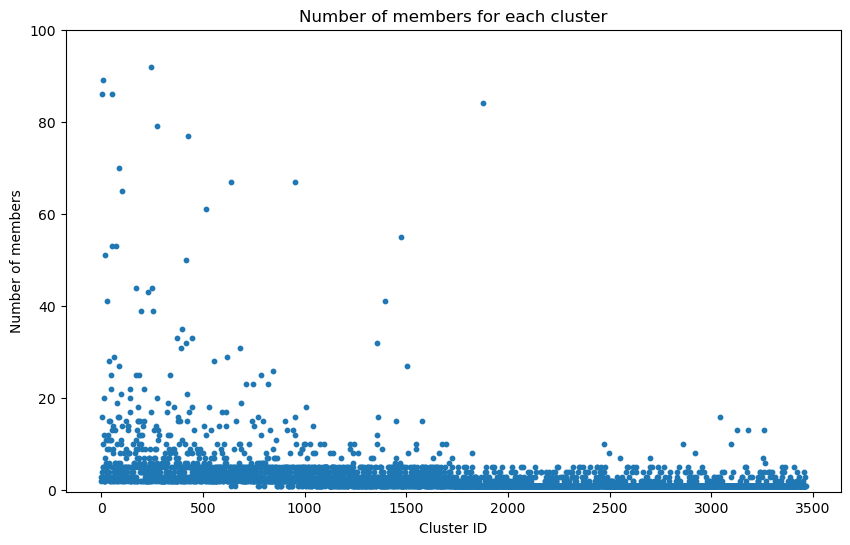

In [264]:
plt.figure(figsize=(10, 6))
plt.scatter(members_per_clust.index, members_per_clust,s=10)
plt.ylim(-0.3,100)
plt.xlabel('Cluster ID')
plt.ylabel('Number of members')
plt.title('Number of members for each cluster')
plt.show()

We still observe clusters with very high number of members, but less compared to the number of members obtained 
implementing the Hierachical clustering on raw sequences data

In [265]:
data = {"cluster_id":range(0,len(entropy_list)),"Entropy":entropy_list,"number_of_members":members_per_clust}
df = pd.DataFrame(data)


In [266]:
true_5_members = df[(df["Entropy"]==0) & (df["number_of_members"]==5)]
true_5_members.shape[0]

257

The implementation of Hierarchical clustering of IDFvectors is able to correctly clusterize the sequences of 257 out of 1561
species that have exactly 5 sequences, 8 times more than the Genie implementation of the Hierarchical clustering on raw sequences

Text(0.5, 1.0, 'Cluster ID vs Number of  Members')

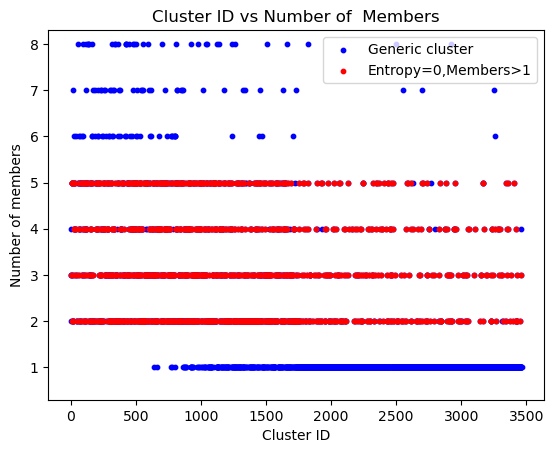

In [267]:
filtered_clusters = df[(df['Entropy'] == 0) & (df['number_of_members'] > 1)]
plt.scatter(df['cluster_id'], df['number_of_members'], color='blue', label='Generic cluster',s=10)
plt.scatter(filtered_clusters['cluster_id'], filtered_clusters['number_of_members'], color='red', label='Entropy=0,Members>1',s=10)


plt.xlabel('Cluster ID')
plt.ylim(0.3,8.3)
plt.ylabel('Number of members')


plt.legend()


plt.title('Cluster ID vs Number of  Members')

if we confront this plot to the ones made on raw sequences data (both with the classical and Genie implementation of Hierarchical)
clustering, we can appreciate how the clusters obtained on IDF vectors are much more homogenous in term of specie composition

In [269]:
data = {"cluster_id":range(0,len(entropy_list_genus)),"Entropy":entropy_list_genus,"number_of_members":members_per_clust}
df = pd.DataFrame(data)

Text(0.5, 1.0, 'Cluster ID vs Number of  Members')

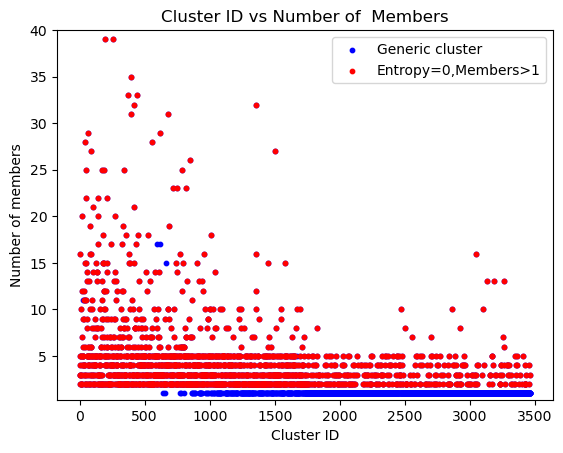

In [270]:
filtered_clusters = df[(df['Entropy'] == 0) & (df['number_of_members'] > 1)]
plt.scatter(df['cluster_id'], df['number_of_members'], color='blue', label='Generic cluster',s=10)
plt.scatter(filtered_clusters['cluster_id'], filtered_clusters['number_of_members'], color='red', label='Entropy=0,Members>1',s=10)


plt.xlabel('Cluster ID')
plt.ylim(0.3,40)
plt.ylabel('Number of members')


plt.legend()


plt.title('Cluster ID vs Number of  Members')

We can appreciate how the clustering applied to IDF vectors return the correct division of our data in genus, in fact all the
clusters made of more than one sequence have 0 entropy, meaning that the genus composition of each cluster is homogenous (beside
                                                                                                                         some outliers)

We now increase the length of the kmer to see if there are increases of the performance of the clustering algorithm

###  Simple Hierarchical clustering using 9-kmers

In [271]:
hierarchical_cluster = AgglomerativeClustering(n_clusters=3465,affinity='precomputed', 
    linkage='average')


In [272]:
clusters = hierarchical_cluster.fit_predict(D_nine)

C:\Simone\anaconda3\lib\site-packages\sklearn\cluster\_agglomerative.py:983: FutureWarning: Attribute `affinity` was deprecated in version 1.2 and will be removed in 1.4. Use `metric` instead
  warnings.warn(


In [273]:
df_dist['Cluster red nine'] = clusters

C:\Users\Simone\AppData\Local\Temp\ipykernel_20848\1804315904.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dist['Cluster red nine'] = clusters


In [274]:
one_seq_df = df_dist[df_dist["ID"].isin(one_seq_ids)].reset_index(drop=True)

In [275]:
clus_idxs = one_seq_df["Cluster red nine"].tolist()

In [276]:
uniq_clus = df_dist[df_dist["Cluster red nine"].isin(clus_idxs)]

In [277]:
one_seq_clus = uniq_clus.groupby("Cluster red nine").filter(lambda x: len(x) == 1)
print(f'there are {one_seq_clus.shape[0]} clusters correctly made of only one member out of 306 true one member clusters')

there are 154 clusters correctly made of only one member out of 306 true one member clusters


Here we can see that the number of true one member clusters is just sligthly higher than the number obtained using kmer of length 6,
but without doubt much more better respect to the results obtained using hierarchical clustering on raw sequences data

In [278]:
species_per_cluster = df_dist.groupby('Cluster red nine')['Specie'].nunique()

In [279]:
species_per_clust_entropy_kmer_9 = df_dist.groupby('Cluster red nine')['Specie']

In [280]:
entropy_list = []
one_seq_clus = 0
zero_entropy_more_than_one = 0
for el in species_per_clust_entropy_kmer_9:
    count = el[1].value_counts(normalize=True)
    if len(el[1]) == 1:
        E = 0
        one_seq_clus = one_seq_clus+1
        entropy_list.append(E)
    else:
        E = -sum(np.log2(count)*count)
        if E == -0.0:
            E = 0
            zero_entropy_more_than_one= zero_entropy_more_than_one+1
            entropy_list.append(E)
        else:
            entropy_list.append(E)

In [281]:
print(f'there are {zero_entropy_more_than_one} clusters that have 0 entropy but they are made of more than one sequence,while there are {one_seq_clus} that have 0 entropy and only one sequence')

there are 1365 clusters that have 0 entropy but they are made of more than one sequence,while there are 1590 that have 0 entropy and only one sequence


Again we observe a small increase in the number of clusters with 0 entropy but more than one sequence and a small decrease in the 
one member clusters respect to the results obtained with kmers of length 6.
In any case the performance of the clustering algorithm on IDF vectors is much more better than the one on raw sequence data

Text(0.5, 1.0, 'Entropy of each cluster')

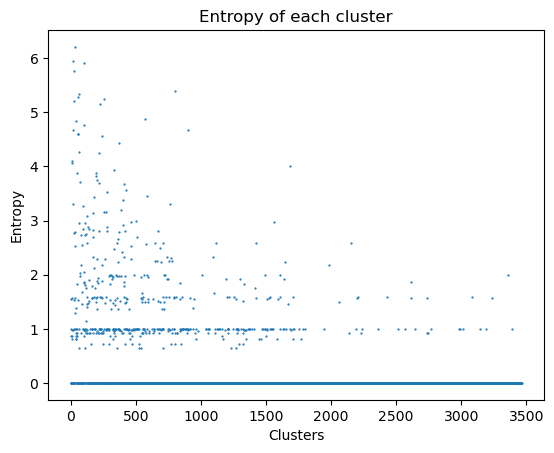

In [282]:
plt.plot(range(len(entropy_list)), entropy_list, 'o',markersize=0.6)

plt.xlabel('Clusters')
plt.ylabel('Entropy')
plt.title('Entropy of each cluster')

Respect to the classical algorithm applied to raw sequences data, we have also less extreme values of Entropy

### Genus composition of each cluster

In [283]:
genus_per_clust_entropy = df_dist.groupby('Cluster red nine')['Genus']

In [284]:
entropy_list_genus = []
one_seq_clus_genus = 0
zero_entropy_more_than_one_genus = 0
for el in genus_per_clust_entropy:
    count = el[1].value_counts(normalize=True)
    if len(el[1]) == 1:
        E = 0
        one_seq_clus_genus = one_seq_clus_genus+1
        entropy_list_genus.append(E)
    else:
        E = -sum(np.log2(count)*count)
        if E == -0.0:
            E = 0
            zero_entropy_more_than_one_genus= zero_entropy_more_than_one_genus+1
            entropy_list_genus.append(E)
        else:
            entropy_list_genus.append(E)
        

Text(0.5, 1.0, 'Entropy of each cluster based on Genus composition')

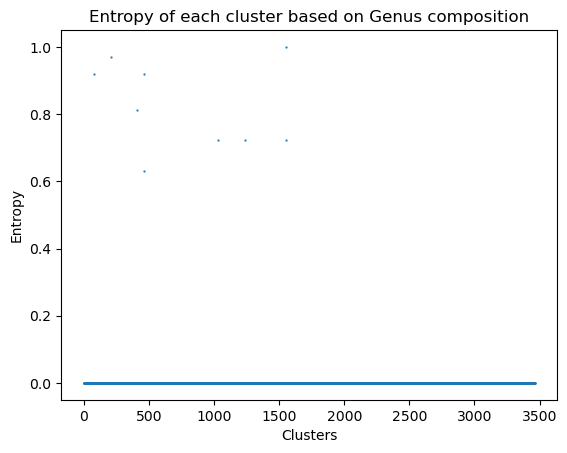

In [285]:
plt.plot(range(len(entropy_list_genus)), entropy_list_genus, 'o',markersize=0.6)

plt.xlabel('Clusters')
plt.ylabel('Entropy')
plt.title('Entropy of each cluster based on Genus composition')

In [286]:
print(f'there are {zero_entropy_more_than_one_genus} clusters that have 0 entropy but they are made of more than one sequence')

there are 1866 clusters that have 0 entropy but they are made of more than one sequence


We observe a tremendous increase of the ability of the clustering algorithm to correctly clusterize IDF vectors respecting the 
genus composition of the dataset

### Family composition of each cluster

In [287]:
family_per_clust_entropy = df_dist.groupby('Cluster red nine')['Family']

In [288]:
entropy_list_fam = []
one_seq_clus_fam = 0
zero_entropy_more_than_one_fam = 0
for el in family_per_clust_entropy:
    count = el[1].value_counts(normalize=True)
    if len(el[1]) == 1:
        E = 0
        one_seq_clus_fam = one_seq_clus_fam+1
        entropy_list_fam.append(E)
    else:
        E = -sum(np.log2(count)*count)
        if E == -0.0:
            E = 0
            zero_entropy_more_than_one_fam= zero_entropy_more_than_one_fam+1
            entropy_list_fam.append(E)
        else:
            entropy_list_fam.append(E)
        

Text(0.5, 1.0, 'Entropy of each cluster based on family composition')

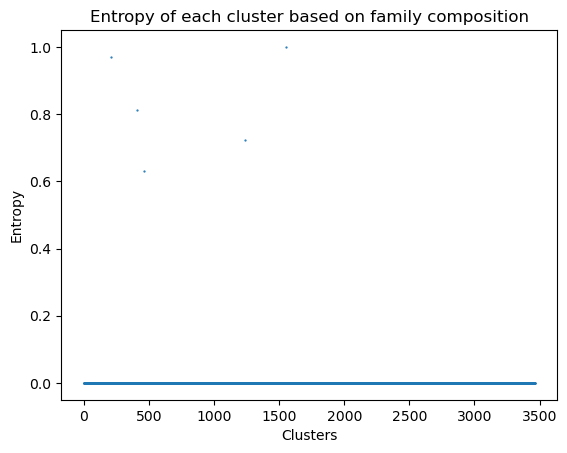

In [289]:
plt.plot(range(len(entropy_list_fam)), entropy_list_fam, 'o',markersize=0.6)

plt.xlabel('Clusters')
plt.ylabel('Entropy')
plt.title('Entropy of each cluster based on family composition')

In [290]:
print(f'there are {zero_entropy_more_than_one_fam} clusters that have 0 entropy but they are made of more than one sequence')

there are 1870 clusters that have 0 entropy but they are made of more than one sequence


### Numerosity Analysis of the clusters

In [291]:
members_per_clust = df_dist.groupby('Cluster red nine').size()

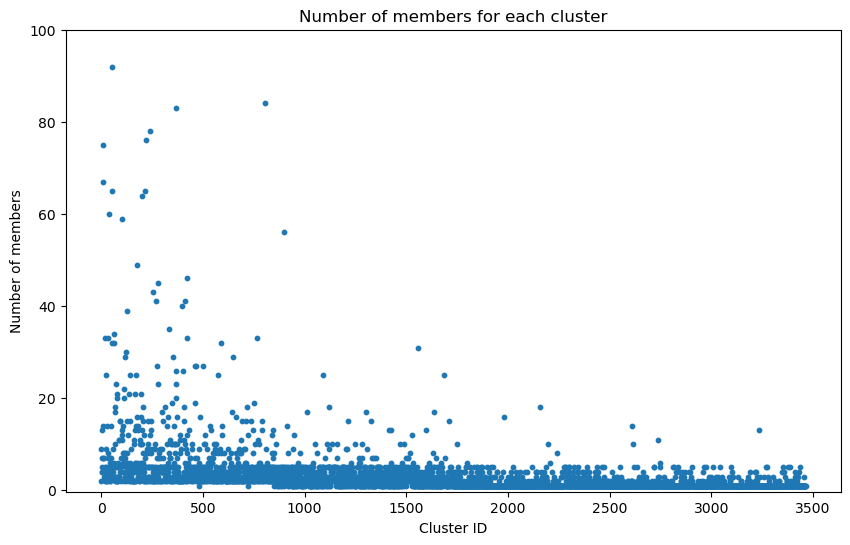

In [292]:
plt.figure(figsize=(10, 6))
plt.scatter(members_per_clust.index, members_per_clust,s=10)
plt.ylim(-0.3,100)
plt.xlabel('Cluster ID')
plt.ylabel('Number of members')
plt.title('Number of members for each cluster')
plt.show()

In [295]:
data = {"cluster_id":range(0,len(entropy_list)),"Entropy":entropy_list,"number_of_members":members_per_clust}
df = pd.DataFrame(data)


In [296]:
true_5_members = df[(df["Entropy"]==0) & (df["number_of_members"]==5)]
true_5_members.shape[0]

257

We can notice that we identfy the same number of true 5 members cluster using 6-kmers or 9-kmers

Text(0.5, 1.0, 'Cluster ID vs Number of  Members')

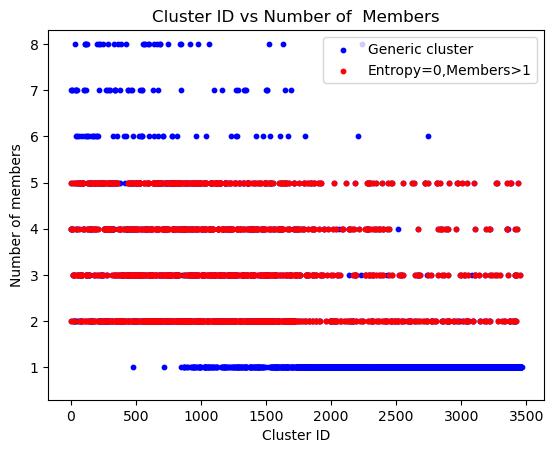

In [297]:
filtered_clusters = df[(df['Entropy'] == 0) & (df['number_of_members'] > 1)]
plt.scatter(df['cluster_id'], df['number_of_members'], color='blue', label='Generic cluster',s=10)
plt.scatter(filtered_clusters['cluster_id'], filtered_clusters['number_of_members'], color='red', label='Entropy=0,Members>1',s=10)


plt.xlabel('Cluster ID')
plt.ylim(0.3,8.3)
plt.ylabel('Number of members')


plt.legend()


plt.title('Cluster ID vs Number of  Members')

In [298]:
data = {"cluster_id":range(0,len(entropy_list_genus)),"Entropy":entropy_list_genus,"number_of_members":members_per_clust}
df = pd.DataFrame(data)
df

,cluster_id,Entropy,number_of_members
Cluster red nine,,,
0,0,0.0,9
1,1,0.0,2
2,2,0.0,13
3,3,0.0,5
4,4,0.0,4
...,...,...,...
3460,3460,0.0,1
3461,3461,0.0,1
3462,3462,0.0,1


Text(0.5, 1.0, 'Cluster ID vs Number of  Members')

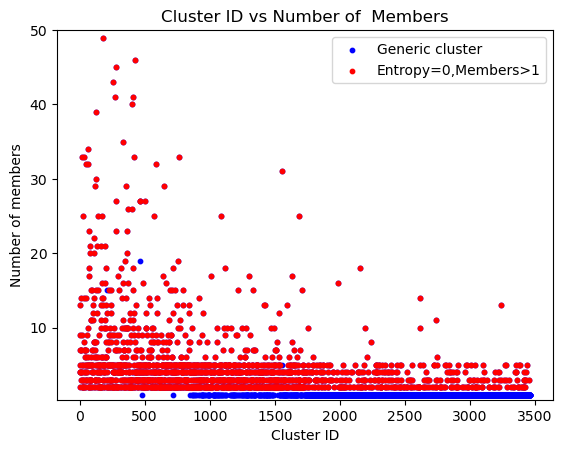

In [299]:
filtered_clusters = df[(df['Entropy'] == 0) & (df['number_of_members'] > 1)]
plt.scatter(df['cluster_id'], df['number_of_members'], color='blue', label='Generic cluster',s=10)
plt.scatter(filtered_clusters['cluster_id'], filtered_clusters['number_of_members'], color='red', label='Entropy=0,Members>1',s=10)


plt.xlabel('Cluster ID')
plt.ylim(0.3,50)
plt.ylabel('Number of members')


plt.legend()


plt.title('Cluster ID vs Number of  Members')

We can appreciate how the clustering applied to IDF vectors return the correct division of our data in genus, in fact all the clusters made of more than one sequence have 0 entropy, meaning that the genus composition of each cluster is homogenous (beside some outliers)

We can notice that the perfomances of the clustering algorithm did not increase significantly using kmer of length 6 or 9,
so I have decided to limit my analysis to the kmers of these lengths.
In addition to this, as we increase the length of kmers, we increase the dimensionality of the IDF vectors and distance based
clustering algorithms could not perform well in these high dimensionality settings

### Genie implementation of the Hierarchical clustering on the IDF vectors

### 6-kmer

In [300]:
hier = genieclust.Genie(n_clusters=3465,gini_threshold=0.3, M=1, affinity='precomputed', exact=True)

In [301]:
hier.fit(D_6, y=None)

Genie(affinity='precomputed', n_clusters=3465)

In [302]:
pred_clus = hier.labels_

In [303]:
df_copy['Cluster 6'] = pred_clus

In [304]:
one_seq_df_g = df_copy[df_copy["ID"].isin(one_seq_ids)].reset_index(drop=True)

In [305]:
clus_idxs_g = one_seq_df_g["Cluster 6"].tolist()

In [306]:
uniq_clus_g = df_copy[df_copy["Cluster 6"].isin(clus_idxs_g)]

In [307]:
one_seq_clus_g = uniq_clus_g.groupby("Cluster 6").filter(lambda x: len(x) == 1)
print(f'there are {one_seq_clus_g.shape[0]} clusters correctly made of only one member out of 306 true one member clusters')

there are 71 clusters correctly made of only one member out of 306 true one member clusters


The results obtained with Genie implementation of Hierarchical clustering on IDF vectors is much more better than the one obtained
on raw sequences data. 
In fact this method correctly identify 71 out 306 true one member cluster, while the implementation on raw sequence data only
identified 1 out of 306 true one member cluster.
We note that this implementation has correctly identified half of the true one member clusters with respect to the classical 
implementation of Hierarchical clustering on IDF vectors, but this is a property of Genie algorithm.
In order to not have highly disbalanced clusters, it gives some members of highly numerous clusters to the 1 member clusters.


### Entropy Analysis

In [308]:
species_per_cluster_g = df_copy.groupby('Cluster 6')['Specie']

In [309]:
entropy_list_g = []
one_seq_clus_g = 0
zero_entropy_more_than_one_g = 0
for el in species_per_cluster_g:
    count = el[1].value_counts(normalize=True)
    if len(el[1]) == 1:
        E = 0
        one_seq_clus_g = one_seq_clus_g+1
        entropy_list_g.append(E)
    else:
        E = -sum(np.log2(count)*count)
        if E == -0.0:
            E = 0
            zero_entropy_more_than_one_g= zero_entropy_more_than_one_g+1
            entropy_list_g.append(E)
        else:
            entropy_list_g.append(E)

In [310]:
print(f'there are {zero_entropy_more_than_one_g} clusters that have 0 entropy but they are made of more than one sequence,while there are {one_seq_clus_g} that have 0 entropy and only one sequence')

there are 2127 clusters that have 0 entropy but they are made of more than one sequence,while there are 189 that have 0 entropy and only one sequence


We note an increase in both the number of clusters with 0 entropy and multiple sequences and the number of clusters with only 
one sequence compared to the clusters obtained implementing the Genie algorithm on raw sequence data

Text(0.5, 1.0, 'Entropy of each cluster')

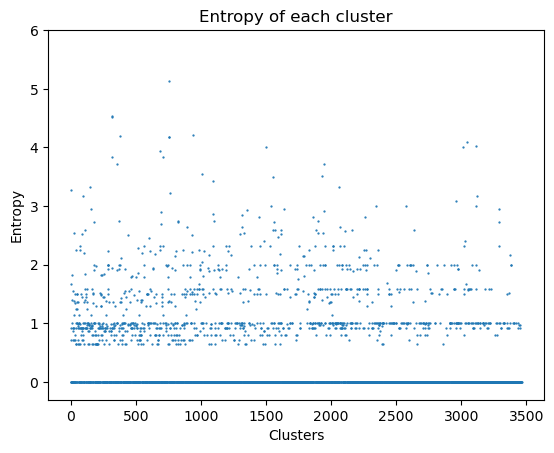

In [311]:
plt.plot(range(len(entropy_list_g)), entropy_list_g, 'o',markersize=0.6)
plt.ylim(-0.3,6)
plt.xlabel('Clusters')
plt.ylabel('Entropy')
plt.title('Entropy of each cluster')

As we can appreciate from the plot, vast majority of clusters has 0 entropy and between those only a small fraction is made of
one member clusters,which have by definition 0 entropy.

### Genus composition of each cluster

In [316]:
genus_per_clust_entropy_g = df_copy.groupby('Cluster 6')['Genus']

In [317]:
entropy_list_g_g = []
one_seq_clus_g_g = 0
zero_entropy_more_than_one_g_g = 0
for el in genus_per_clust_entropy_g:
    count = el[1].value_counts(normalize=True)
    if len(el[1]) == 1:
        E = 0
        one_seq_clus_g_g = one_seq_clus_g_g+1
        entropy_list_g_g.append(E)
    else:
        E = -sum(np.log2(count)*count)
        if E == -0.0:
            E = 0
            zero_entropy_more_than_one_g_g= zero_entropy_more_than_one_g_g+1
            entropy_list_g_g.append(E)
        else:
            entropy_list_g_g.append(E)

Text(0.5, 1.0, 'Entropy of each cluster based on Genus composition')

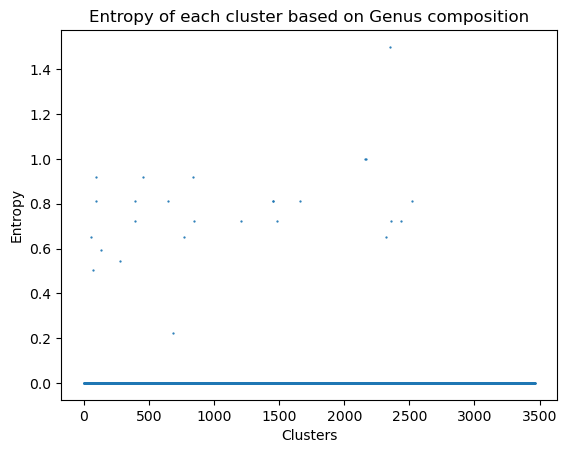

In [318]:
plt.plot(range(len(entropy_list_g_g)), entropy_list_g_g, 'o',markersize=0.6)

plt.xlabel('Clusters')
plt.ylabel('Entropy')
plt.title('Entropy of each cluster based on Genus composition')

We can notice a tremendous increase of the performance of the clustering algorithm. We can see that almost every cluster has 0 entropy, and just few outliers have entropy values of their cluster greater than 0 but lower than 1.5, while the clusters obtained on raw sequences data had much many clusters with entropy greater than 0, also with bigger values of entropy.
We also have much less clusters made of only one sequence, which are associated to 0 entropy values
So the vast majority of clusters have a very homogenous composition in term of Genus inside a cluster

In [319]:
print(f'there are {zero_entropy_more_than_one_g_g} clusters that have 0 entropy but they are made of more than one sequence')

there are 3250 clusters that have 0 entropy but they are made of more than one sequence


### Family composition of each cluster

In [320]:
family_per_clust_entropy_g = df_copy.groupby('Cluster 6')['Family']

In [321]:
entropy_list_fam_g = []
one_seq_clus_fam_g = 0
zero_entropy_more_than_one_fam_g = 0
for el in family_per_clust_entropy_g:
    count = el[1].value_counts(normalize=True)
    if len(el[1]) == 1:
        E = 0
        one_seq_clus_fam_g = one_seq_clus_fam_g+1
        entropy_list_fam_g.append(E)
    else:
        E = -sum(np.log2(count)*count)
        if E == -0.0:
            E = 0
            zero_entropy_more_than_one_fam_g= zero_entropy_more_than_one_fam_g+1
            entropy_list_fam_g.append(E)
        else:
            entropy_list_fam_g.append(E)

Text(0.5, 1.0, 'Entropy of each cluster based on family composition')

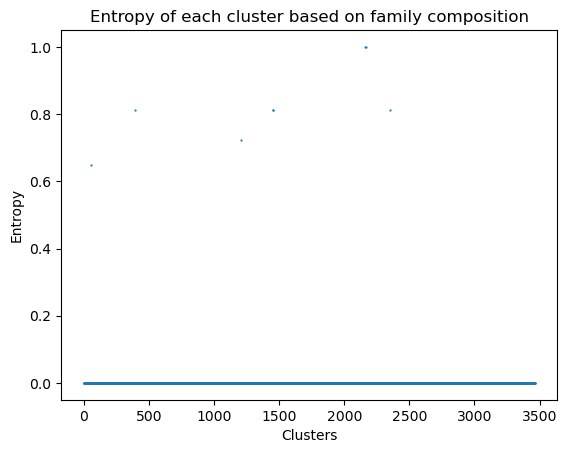

In [322]:
plt.plot(range(len(entropy_list_fam_g)), entropy_list_fam_g, 'o',markersize=0.6)

plt.xlabel('Clusters')
plt.ylabel('Entropy')
plt.title('Entropy of each cluster based on family composition')

### numerosity distribution of the clustering algorithm

In [323]:
members_per_clust_g = df_copy.groupby('Cluster 6').size()

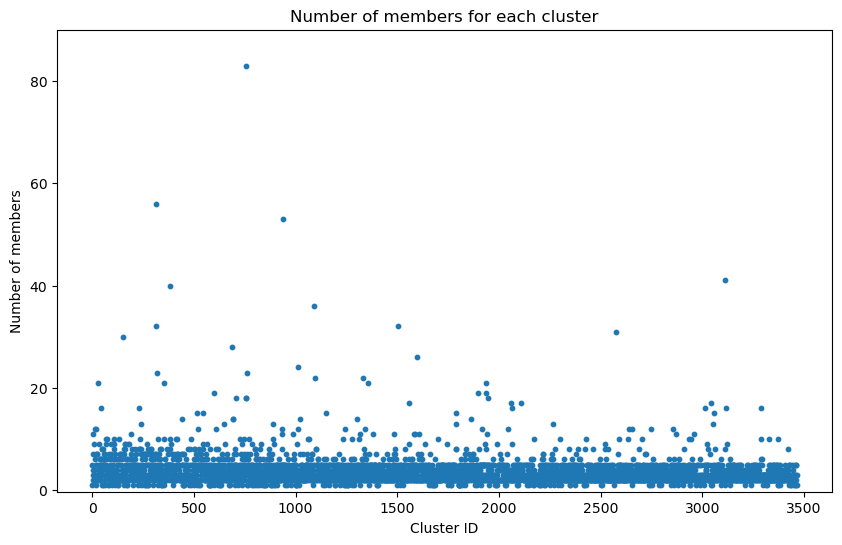

In [324]:
plt.figure(figsize=(10, 6))
plt.scatter(members_per_clust_g.index, members_per_clust_g,s=10)
plt.ylim(-0.3,90)
plt.xlabel('Cluster ID')
plt.ylabel('Number of members')
plt.title('Number of members for each cluster')
plt.show()

In [326]:
data = {"cluster_id":range(0,len(entropy_list)),"Entropy":entropy_list_g,"number_of_members":members_per_clust_g}
df_g = pd.DataFrame(data)


In [327]:
true_5_members = df_g[(df_g["Entropy"]==0) & (df_g["number_of_members"]==5)]
true_5_members.shape[0]

434

The implementation of Genie Hierarchical clustering of IDFvectors is able to correctly clusterize the sequences of 434 out of 1561 species that have exactly 5 sequences, 10 times more than the Genie implementation of the Hierarchical clustering on raw sequences

Text(0.5, 1.0, 'Cluster ID vs Number of Members')

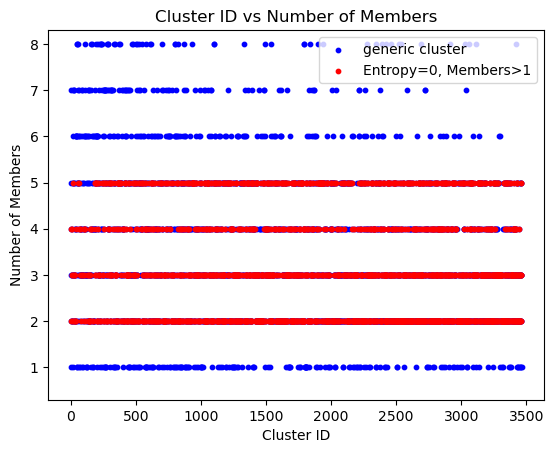

In [328]:
filtered_clusters = df_g[(df_g['Entropy'] == 0) & (df_g['number_of_members'] > 1)]

plt.scatter(df_g['cluster_id'], df_g['number_of_members'], color='blue', label='generic cluster',s=10)
plt.scatter(filtered_clusters['cluster_id'], filtered_clusters['number_of_members'], color='red', label='Entropy=0, Members>1',s=10)

plt.xlabel('Cluster ID')
plt.ylim(0.3,8.3)
plt.ylabel('Number of Members')
plt.legend()


plt.title('Cluster ID vs Number of Members')

In [331]:
data = {"cluster_id":range(0,len(entropy_list_g_g)),"Entropy":entropy_list_g_g,"number_of_members":members_per_clust_g}
df = pd.DataFrame(data)


Text(0.5, 1.0, 'Cluster ID vs Number of Members')

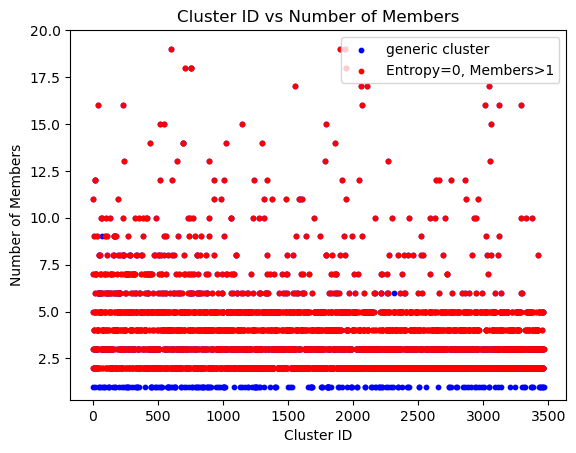

In [332]:
filtered_clusters = df[(df['Entropy'] == 0) & (df['number_of_members'] > 1)]

plt.scatter(df['cluster_id'], df['number_of_members'], color='blue', label='generic cluster',s=10)
plt.scatter(filtered_clusters['cluster_id'], filtered_clusters['number_of_members'], color='red', label='Entropy=0, Members>1',s=10)

plt.xlabel('Cluster ID')
plt.ylim(0.3,20)
plt.ylabel('Number of Members')
plt.legend()


plt.title('Cluster ID vs Number of Members')

We can notice how the clustering algorithm is able to capture the genus composition of our dataset

### 9-kmer

In [333]:
hier = genieclust.Genie(n_clusters=3465,gini_threshold=0.3, M=1, affinity='precomputed', exact=True)

In [334]:
hier.fit(D_nine, y=None)

Genie(affinity='precomputed', n_clusters=3465)

In [335]:
pred_clus = hier.labels_

In [336]:
df_copy['Cluster 9'] = pred_clus

In [337]:
one_seq_df_g = df_copy[df_copy["ID"].isin(one_seq_ids)].reset_index(drop=True)

In [338]:
clus_idxs_g = one_seq_df_g["Cluster 9"].tolist()

In [339]:
uniq_clus_g = df_copy[df_copy["Cluster 9"].isin(clus_idxs_g)]

In [340]:
one_seq_clus_g = uniq_clus_g.groupby("Cluster 9").filter(lambda x: len(x) == 1)
print(f'there are {one_seq_clus_g.shape[0]} clusters correctly made of only one member out of 306 true one member clusters')

there are 88 clusters correctly made of only one member out of 306 true one member clusters


We notice a small increase in the number of true one member clusters identified using kmers of length 9

### Entropy Analysis

In [341]:
species_per_cluster_g = df_copy.groupby('Cluster 9')['Specie']

In [342]:
entropy_list_g = []
one_seq_clus_g = 0
zero_entropy_more_than_one_g = 0
for el in species_per_cluster_g:
    count = el[1].value_counts(normalize=True)
    if len(el[1]) == 1:
        E = 0
        one_seq_clus_g = one_seq_clus_g+1
        entropy_list_g.append(E)
    else:
        E = -sum(np.log2(count)*count)
        if E == -0.0:
            E = 0
            zero_entropy_more_than_one_g= zero_entropy_more_than_one_g+1
            entropy_list_g.append(E)
        else:
            entropy_list_g.append(E)

In [343]:
print(f'there are {zero_entropy_more_than_one_g} clusters that have 0 entropy but they are made of more than one sequence,while there are {one_seq_clus_g} that have 0 entropy and only one sequence')

there are 2078 clusters that have 0 entropy but they are made of more than one sequence,while there are 213 that have 0 entropy and only one sequence


We notice a decrease in the number of clusters with 0 entropy and multiple sequences and an increase in the number of clusters with
only one member respect to the number of clusters obtained using the Genie algorithm on kmers of length 6

Text(0.5, 1.0, 'Entropy of each cluster')

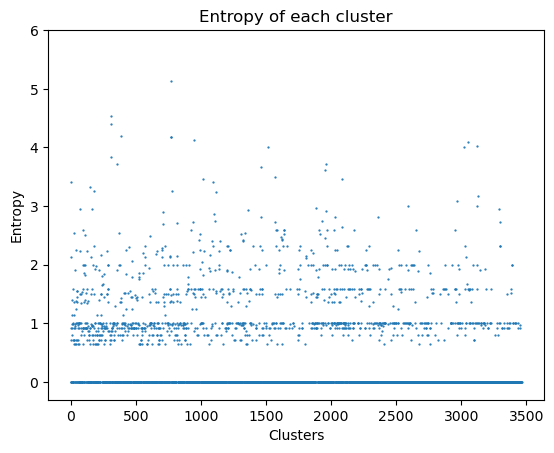

In [344]:
plt.plot(range(len(entropy_list_g)), entropy_list_g, 'o',markersize=0.6)
plt.ylim(-0.3,6)
plt.xlabel('Clusters')
plt.ylabel('Entropy')
plt.title('Entropy of each cluster')

### Genus composition of each cluster

In [345]:
genus_per_clust_entropy_g = df_copy.groupby('Cluster 9')['Genus']

In [346]:
entropy_list_g_g = []
one_seq_clus_g_g = 0
zero_entropy_more_than_one_g_g = 0
for el in genus_per_clust_entropy_g:
    count = el[1].value_counts(normalize=True)
    if len(el[1]) == 1:
        E = 0
        one_seq_clus_g_g = one_seq_clus_g_g+1
        entropy_list_g_g.append(E)
    else:
        E = -sum(np.log2(count)*count)
        if E == -0.0:
            E = 0
            zero_entropy_more_than_one_g_g= zero_entropy_more_than_one_g_g+1
            entropy_list_g_g.append(E)
        else:
            entropy_list_g_g.append(E)

Text(0.5, 1.0, 'Entropy of each cluster based on Genus composition')

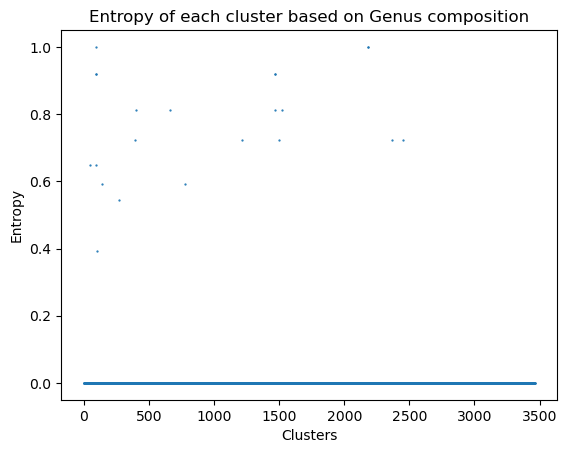

In [347]:
plt.plot(range(len(entropy_list_g_g)), entropy_list_g_g, 'o',markersize=0.6)

plt.xlabel('Clusters')
plt.ylabel('Entropy')
plt.title('Entropy of each cluster based on Genus composition')

Again, we observe that almost every cluster has a homogenous genus composition, beside few outliers which values of entropy are
relatively low (lower than 1).

In [348]:
print(f'there are {zero_entropy_more_than_one_g_g} clusters that have 0 entropy but they are made of more than one sequence')

there are 3230 clusters that have 0 entropy but they are made of more than one sequence


### Family composition of each cluster

In [349]:
family_per_clust_entropy_g = df_copy.groupby('Cluster 9')['Family']

In [350]:
entropy_list_fam_g = []
one_seq_clus_fam_g = 0
zero_entropy_more_than_one_fam_g = 0
for el in family_per_clust_entropy_g:
    count = el[1].value_counts(normalize=True)
    if len(el[1]) == 1:
        E = 0
        one_seq_clus_fam_g = one_seq_clus_fam_g+1
        entropy_list_fam_g.append(E)
    else:
        E = -sum(np.log2(count)*count)
        if E == -0.0:
            E = 0
            zero_entropy_more_than_one_fam_g= zero_entropy_more_than_one_fam_g+1
            entropy_list_fam_g.append(E)
        else:
            entropy_list_fam_g.append(E)

Text(0.5, 1.0, 'Entropy of each cluster based on family composition')

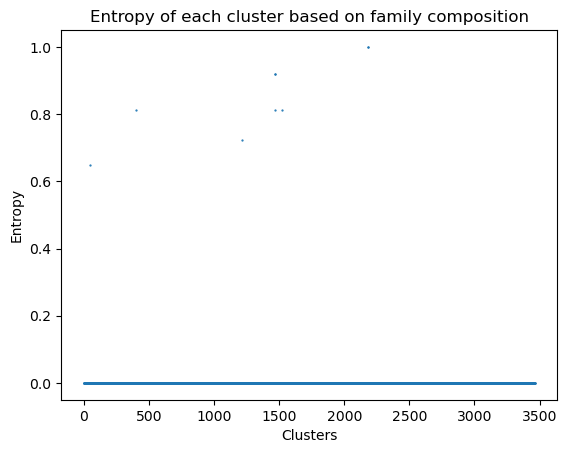

In [351]:
plt.plot(range(len(entropy_list_fam_g)), entropy_list_fam_g, 'o',markersize=0.6)

plt.xlabel('Clusters')
plt.ylabel('Entropy')
plt.title('Entropy of each cluster based on family composition')

### numerosity distribution of the clustering algorithm

In [352]:
members_per_clust_g = df_copy.groupby('Cluster 9').size()

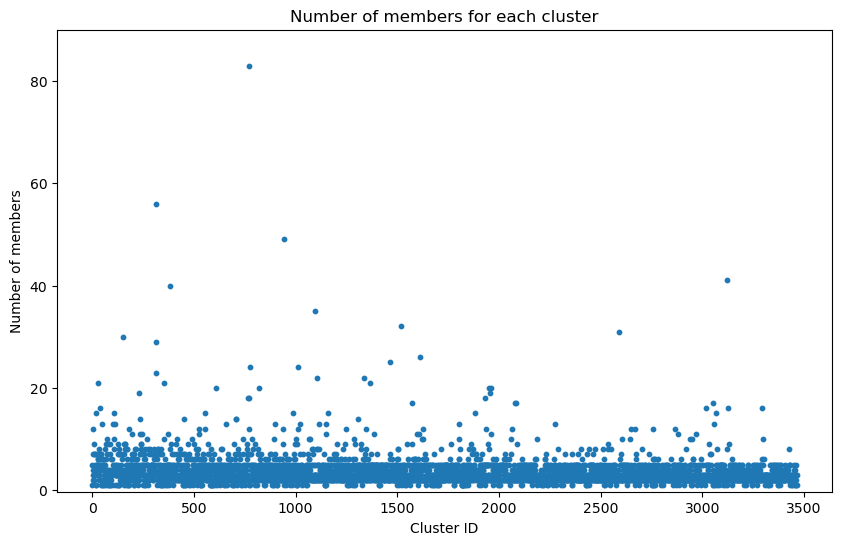

In [353]:
plt.figure(figsize=(10, 6))
plt.scatter(members_per_clust_g.index, members_per_clust_g,s=10)
plt.ylim(-0.3,90)
plt.xlabel('Cluster ID')
plt.ylabel('Number of members')
plt.title('Number of members for each cluster')
plt.show()

In [354]:
data = {"cluster_id":range(0,len(entropy_list_g)),"Entropy":entropy_list_g,"number_of_members":members_per_clust_g}
df_g = pd.DataFrame(data)


In [355]:
true_5_members = df_g[(df_g["Entropy"]==0) & (df_g["number_of_members"]==5)]
true_5_members.shape[0]

432

The implementation of Genie Hierarchical clustering of IDFvectors is able to correctly clusterize the sequences of 432 out of 1561 species that have exactly 5 sequences, 10 times more than the Genie implementation of the Hierarchical clustering on raw sequences
As we can see, the performance does not vary much if we use kmers of length 6 or 9 (434 vs 432 correctly identified 5 members cluster)

In [356]:
one_seq_one_mem = df_g[(df_g["Entropy"] == 0) & (df_g["number_of_members"] == 1)]

Text(0.5, 1.0, 'Cluster ID vs Number of Members')

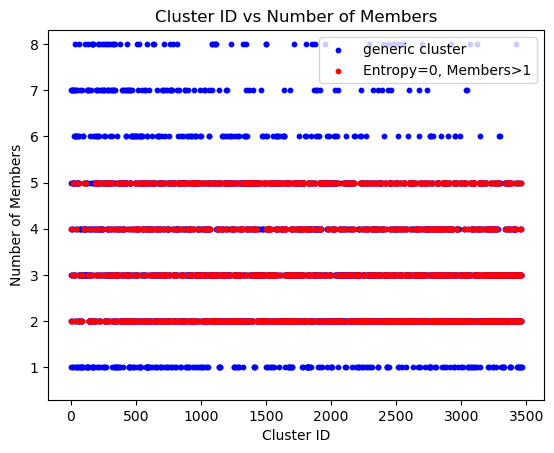

In [357]:
filtered_clusters = df_g[(df_g['Entropy'] == 0) & (df_g['number_of_members'] > 1)]

plt.scatter(df_g['cluster_id'], df_g['number_of_members'], color='blue', label='generic cluster',s=10)
plt.scatter(filtered_clusters['cluster_id'], filtered_clusters['number_of_members'], color='red', label='Entropy=0, Members>1',s=10)

plt.xlabel('Cluster ID')
plt.ylim(0.3,8.3)
plt.ylabel('Number of Members')
plt.legend()


plt.title('Cluster ID vs Number of Members')

In [360]:
data = {"cluster_id":range(0,len(entropy_list_g_g)),"Entropy":entropy_list_g_g,"number_of_members":members_per_clust_g}
df = pd.DataFrame(data)

Text(0.5, 1.0, 'Cluster ID vs Number of Members')

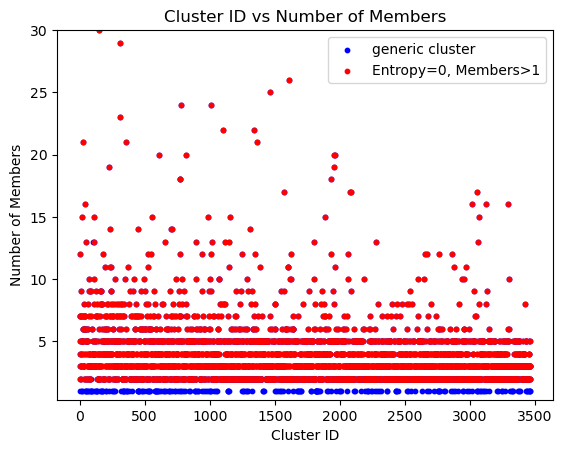

In [362]:
filtered_clusters = df[(df['Entropy'] == 0) & (df['number_of_members'] > 1)]

plt.scatter(df['cluster_id'], df['number_of_members'], color='blue', label='generic cluster',s=10)
plt.scatter(filtered_clusters['cluster_id'], filtered_clusters['number_of_members'], color='red', label='Entropy=0, Members>1',s=10)

plt.xlabel('Cluster ID')
plt.ylim(0.3,30)
plt.ylabel('Number of Members')
plt.legend()


plt.title('Cluster ID vs Number of Members')

We can notice how the clustering algorithm is able to capture the genus composition of our dataset

### Conclusions

We have seen that both for clustering and classification, we obtain better results using the IDF representation of a DNA string
instead of using the sequence itself for computing pairwise distances.

Since the number of sequences for each organism is more or less homogenous, the Genie implementation of Hierarchical clustering
works better because we do not expect to find highly embalanced clusters.
It is not a general rule but more a result of how the dataset was built.

As we increase the length of the kmer, we are able to increase the accuracy of our classifier.
When performing dimensionality reduction and using a fixed number of principle components for each kmer results in reduced information
loss for shorter kmers compared to longer ones.

For obtaining more accurate results it is necessary to increase the number of sequences per organism and the number of microorganisms
in general, to have a better representation of the variability in sequences and in 16S copy number.